# Frankenstein (orbits 1+2+3+4, "narrower_1M" config) vs. SFA RESI

Analysis of the `Frankenstein_He_electron2_orbit1234only_narrower_1M` CQSFA_fwd run: a follow-up
to the `_narrower` run (itself `C=1`, H-like target, `Ip=0.5`, `+/-3.5` momentum axis), now with
**much stronger Coulomb rescattering** (`aSoft=0.001`, down from `0.1`) and **10x more statistics**
(`NInitCond=1000000`, up from `100000`) - both aimed at surfacing genuine high-energy,
Coulomb-driven rescattering content that the previous run's tail statistics may have missed (see
Section 5 of `Frankenstein_orbit1234_narrower.ipynb`). Still all four orbit types included
coherently (`includeOrbits = [1, 2, 3, 4]`) in a single native run.

Three checks, all reusing the validated `Source/CQSFA.py` library and the same patterns as
`Per_Orbit_Amplitude.ipynb` / `scatter_plots_helium.ipynb` / `Frankenstein_vs_SFA_RESI.ipynb`:
1. **Momentum distribution** - CQSFA_fwd's own native `Amplitude_Grid` (bare / physical / qPref).
2. **Orbits** - `Binned_Initial_Condition_Grid` scatter, colored/split by orbit type.
3. **Frankenstein vs. SFA RESI** - per-orbit CQSFA native times/qPref reconstructed on

   OrbitFinder's own grid, coherently summed over all 4 orbit types, compared to the   Coulomb-free SFA RESI (long branch) reference.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
import time

ATTOPYTHON_ROOT = "/workspaces/CQSFA/AttoPython"
if ATTOPYTHON_ROOT not in sys.path:
    sys.path.insert(0, ATTOPYTHON_ROOT)

import importlib
import Source.CQSFA
importlib.reload(Source.CQSFA)  # kernel may already have an older cached copy of this module
from Source.CQSFA import RESIParams, load_orbit, compute_electron1_times, compute_M, compute_M_native

CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit1234only_narrower_1M"
RUN_TAG = "orbit1234only_narrower_1M"
NINITCOND_TAG = "1e+06"  # NInitCond is stream-formatted as a double -> "1e+06", not "1000000"
AMP_GRID_TAG = "500X500X1"
Nz = Ny = 500

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
GRID_TAG = "141X141"  # OrbitFinder's own p_long x p_trans grid (unaffected by CQSFA aSoft/sigma)

omega = 0.057
Up = 0.6579
Up0 = Up / omega

Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)
BUMP = 1e-4
params = RESIParams(omega=omega, Up0=Up0, Ip1=Ip1, Ip2=Ip2, Ip12=Ip12, BUMP=BUMP)

## 1. Momentum distribution: native `Amplitude_Grid`

Same three quantities as `Per_Orbit_Amplitude.ipynb`: bare $|M|^2$ (no pr, col 5),
physical $|M_{pref}|^2$ (full prefactor, col 8), and $|M_{qpref}|^2$ (stability-only, col 11).

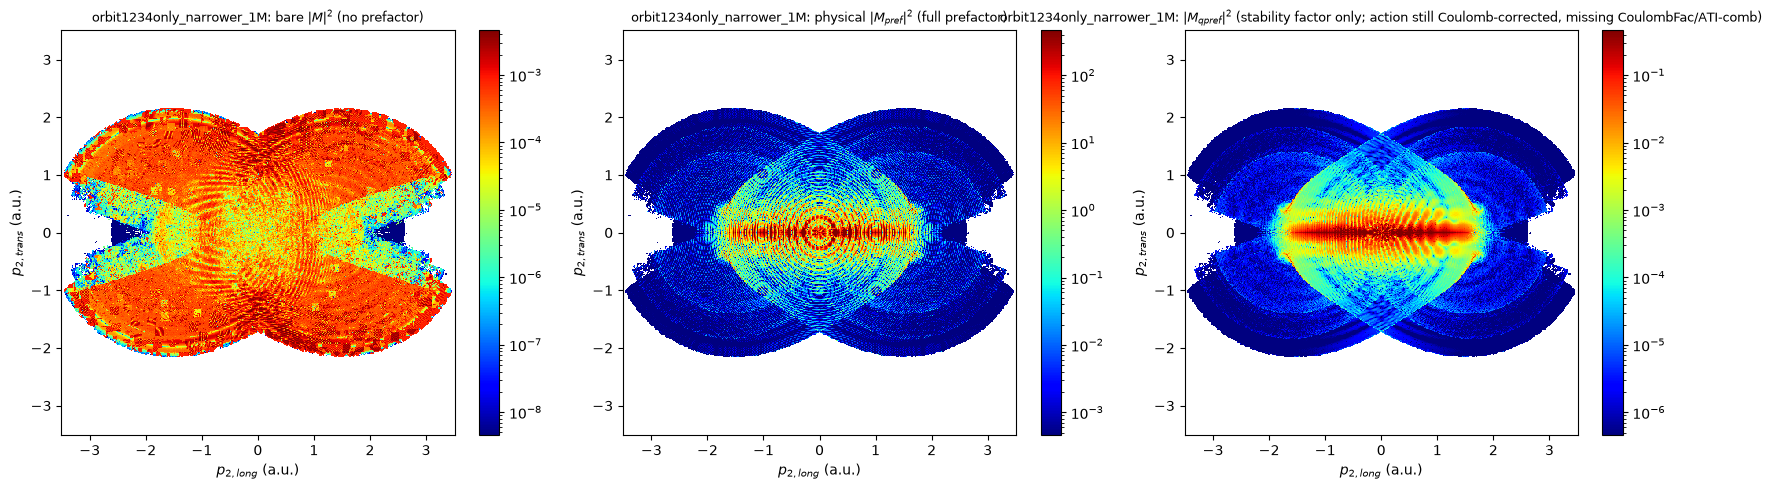

In [60]:
def load_amplitude(orbit_num=None):
    # orbit_num=None -> combined Amplitude_Grid (all included orbits); else the native
    # Amplitude_Grid_orbit<N> breakdown (CQSFA_fwd's outputPerOrbitAmplitude feature).
    prefix = f"Amplitude_Grid_orbit{orbit_num}_" if orbit_num is not None else "Amplitude_Grid_"
    path = f"{CQSFA_dir}/Data/{prefix}Frankenstein_He_electron2_{RUN_TAG}_{AMP_GRID_TAG}.dat"
    amp_data = np.loadtxt(path)
    pz = amp_data[:, 0].reshape(Nz, Ny)[:, 0]
    py = amp_data[:, 1].reshape(Nz, Ny)[0, :]
    # Short, stable keys (avoids brittle long-string dict keys elsewhere); TITLES holds display text.
    quantities = {
        "bare": np.abs(amp_data[:, 5]).reshape(Nz, Ny),
        "full": np.abs(amp_data[:, 8]).reshape(Nz, Ny),
        "qpref": np.abs(amp_data[:, 11]).reshape(Nz, Ny),
    }
    return pz, py, quantities


TITLES = {
    "bare": "bare $|M|^2$ (no prefactor)",
    "full": "physical $|M_{pref}|^2$ (full prefactor)",
    "qpref": "$|M_{qpref}|^2$ (stability factor only; action still Coulomb-corrected, missing CoulombFac/ATI-comb)",
}

pz_amp, py_amp, amp_quantities = load_amplitude()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (key, d) in zip(axes, amp_quantities.items()):
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pz_amp, py_amp, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2,long}$ (a.u.)"); ax.set_ylabel(r"$p_{2,trans}$ (a.u.)")
    ax.set_title(f"{RUN_TAG}: {TITLES[key]}", fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

### Native per-orbit breakdown (`Amplitude_Grid_orbit1..4`)

This run was generated with the new `outputPerOrbitAmplitude=true` config flag (CQSFA_fwd), so
`Data/` also contains a genuinely native (C++-computed) `Amplitude_Grid_orbit<N>` file per orbit
type, reusing the exact same action/prefactor grids as the combined result - no Python
reconstruction/interpolation involved, unlike section 3 below.

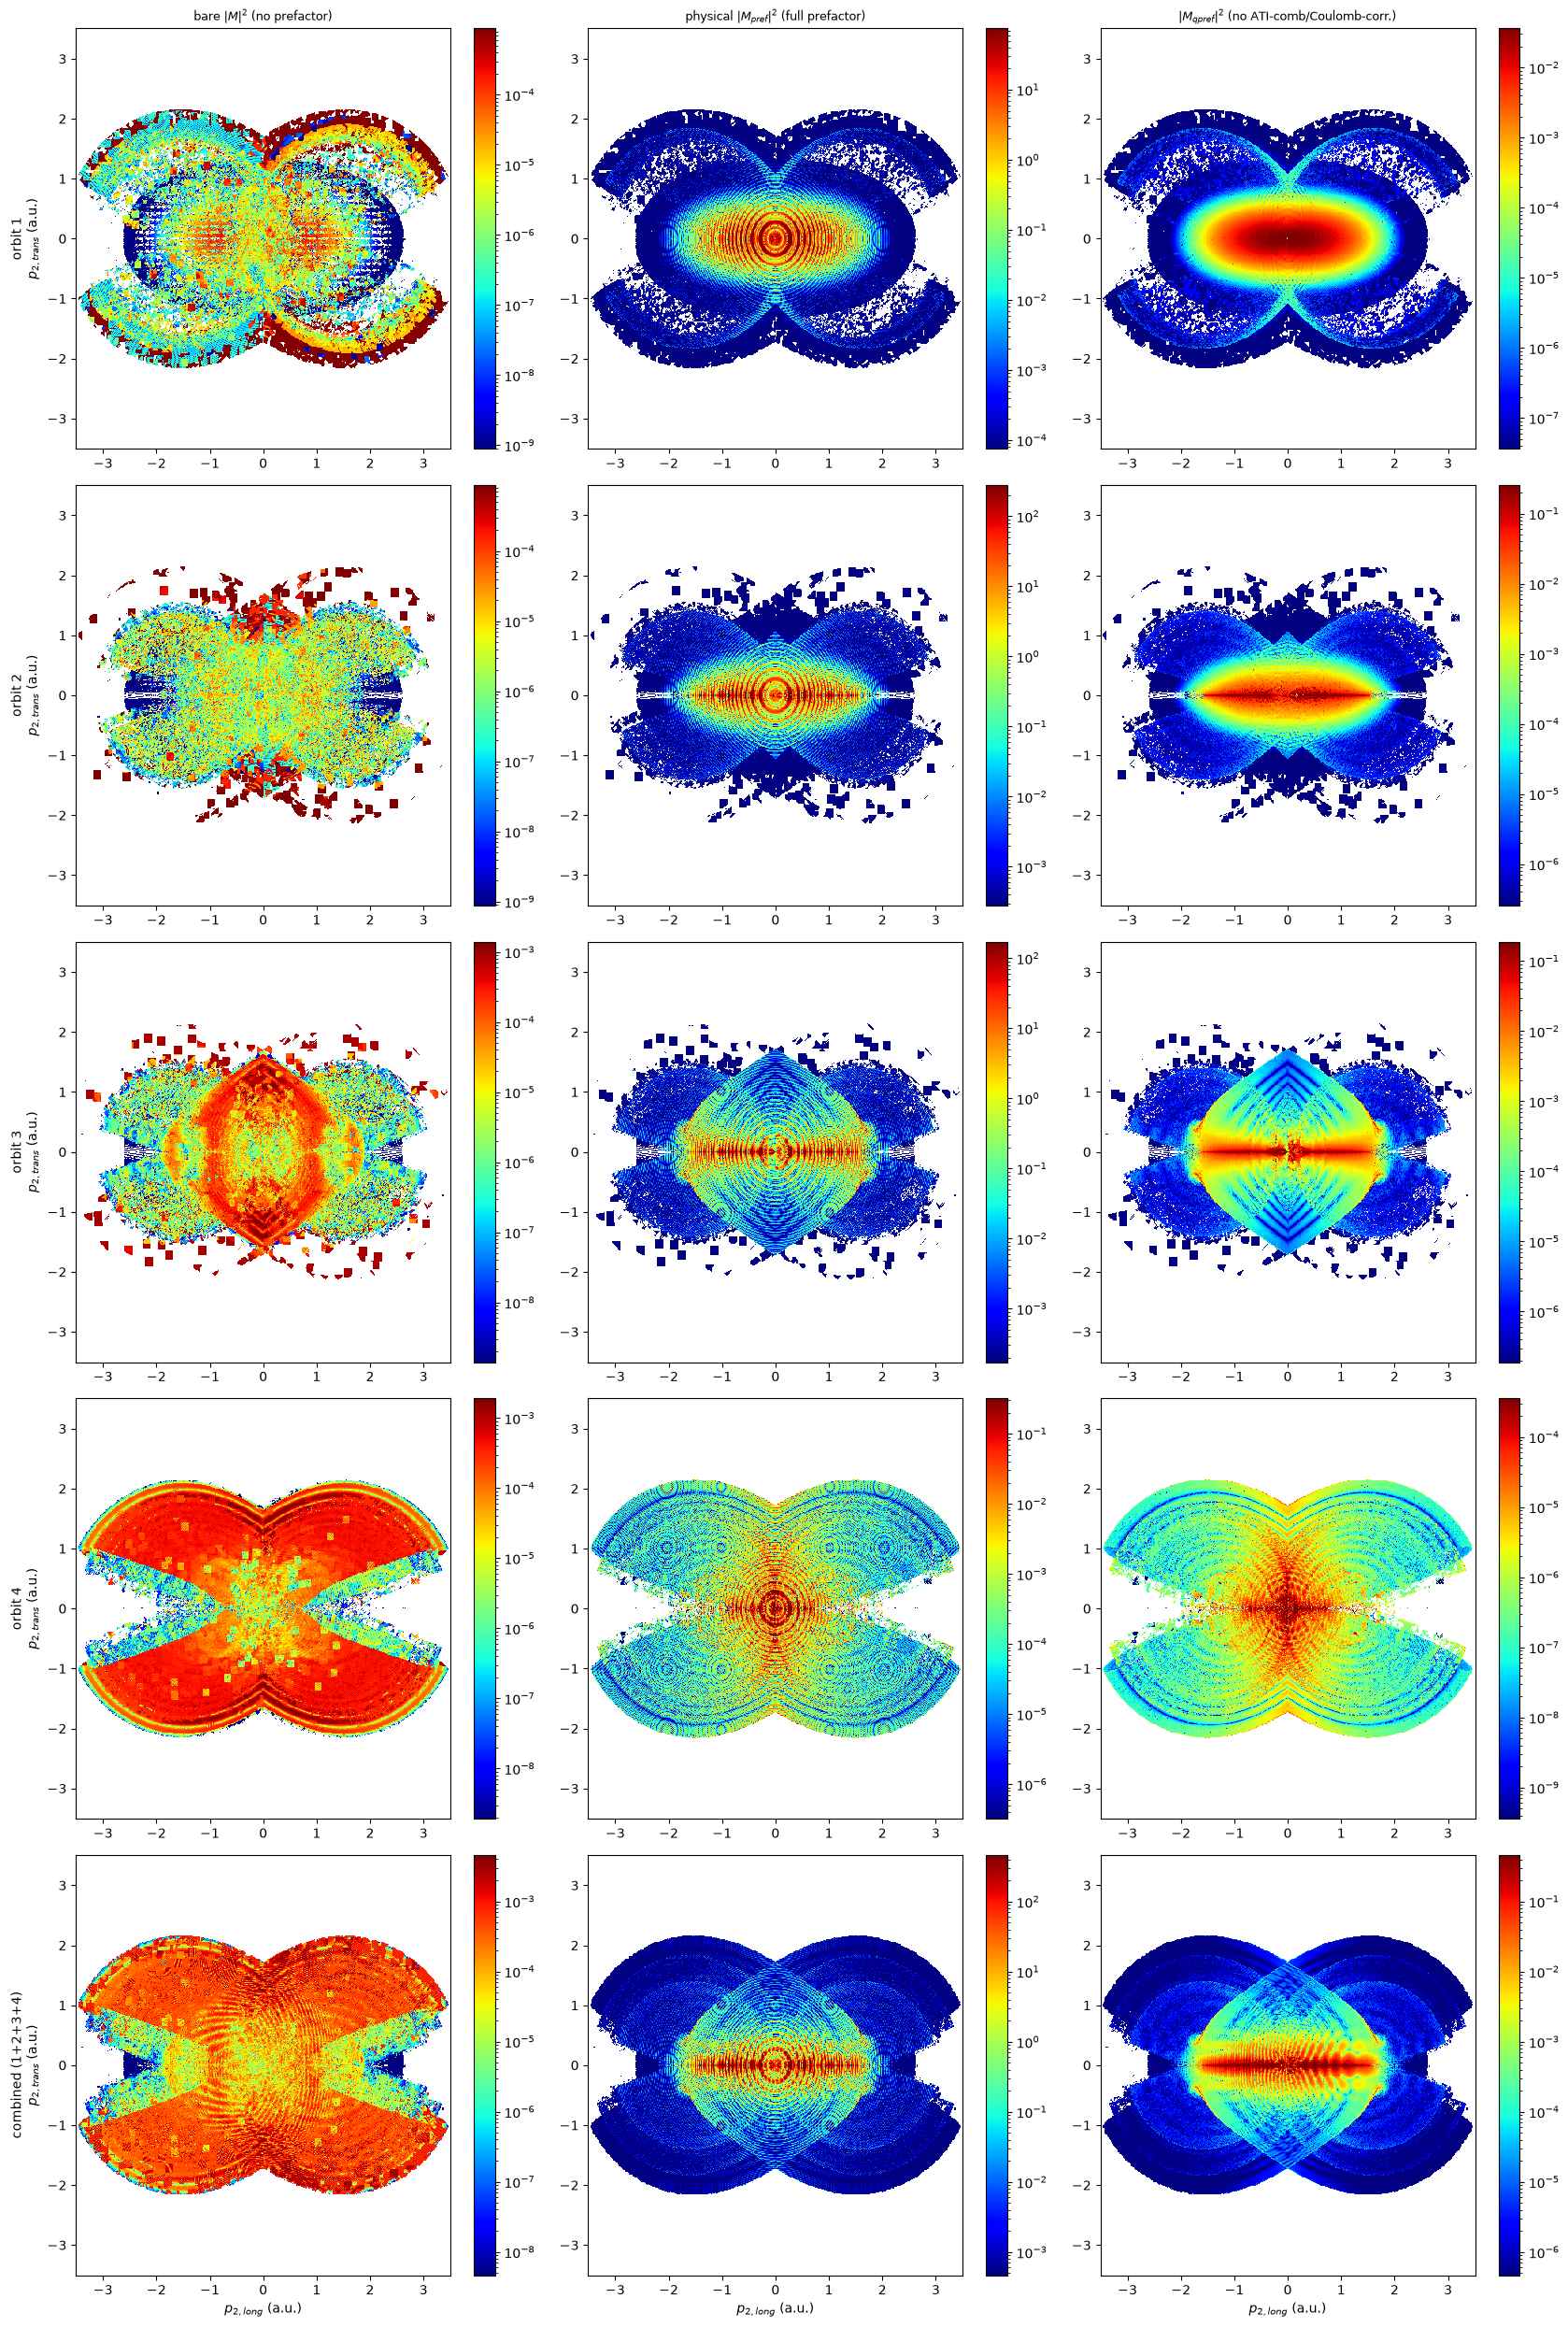

In [ ]:
NATIVE_ORBITS = [1, 2, 3, 4, None]  # None = combined (all included orbits)
NATIVE_LABELS = {1: "orbit 1", 2: "orbit 2", 3: "orbit 3", 4: "orbit 4", None: "combined (1+2+3+4)"}

fig, axes = plt.subplots(len(NATIVE_ORBITS), 3, figsize=(17, 5 * len(NATIVE_ORBITS)))
for row, orbit_num in enumerate(NATIVE_ORBITS):
    pz, py, quantities = load_amplitude(orbit_num)
    label = NATIVE_LABELS[orbit_num]
    for col, (key, d) in enumerate(quantities.items()):
        ax = axes[row, col]
        mask = d > 0
        vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
        pcm = ax.pcolormesh(pz, py, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
        if row == len(NATIVE_ORBITS) - 1:
            ax.set_xlabel(r"$p_{2,long}$ (a.u.)")
        ax.set_ylabel(f"{label}\n" + r"$p_{2,trans}$ (a.u.)" if col == 0 else "")
        if row == 0:
            ax.set_title(TITLES[key], fontsize=9)
        fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

## 2. Orbits: raw `Binned_Initial_Condition_Grid`, split by orbit type

Same pattern as `scatter_plots_helium.ipynb`. Classification follows
`initCondsGrid::pointType()`: orb1 = (z0*pf_par+, pf_perp*p0_perp+), orb2 = (-,+), orb3 = (-,-),
orb4 = (+,-).

Loading Binned_Initial_Condition_Grid....
Loaded 1212635 points, orbit counts:
orbit
1    240138
2    286492
3    296308
4    389697
Name: count, dtype: int64


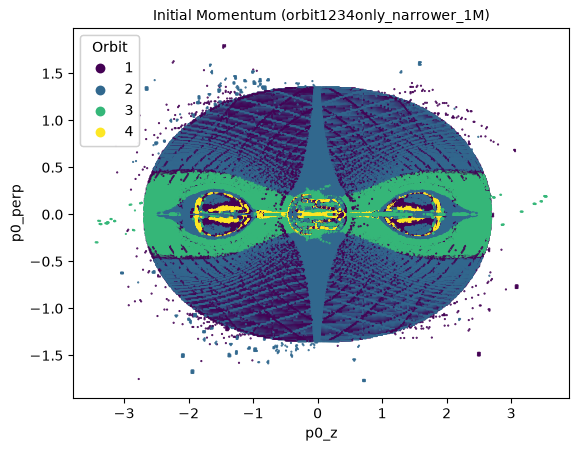

In [4]:
# Same 15-column format as H_800_1e14/Frankenstein_He_electron2 (initCondVars::printVars)
COLUMNS = [
    "p0_z", "p0_perp", "p0_x",
    "t0_re", "t0_im", "z0",
    "pf_z", "pf_perp", "pf_x",
    "orbit",
    "rf_z", "rf_perp", "rf_x",
    "Vmax", "Rmin",
]

print("Loading Binned_Initial_Condition_Grid....")
cqsfa_data = np.loadtxt(f"{CQSFA_dir}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
df = pd.DataFrame(cqsfa_data, columns=COLUMNS)
df["orbit"] = df["orbit"].astype(int)
print(f"Loaded {len(df)} points, orbit counts:")
print(df["orbit"].value_counts().sort_index())

fig, ax = plt.subplots()
scatter = ax.scatter(df["p0_z"], df["p0_perp"], c=df["orbit"], s=0.3, cmap="viridis")
ax.set_title(f"Initial Momentum ({RUN_TAG})", fontsize=10)
ax.set_xlabel("p0_z", fontsize=10)
ax.set_ylabel("p0_perp", fontsize=10)
legend1 = ax.legend(*scatter.legend_elements(), loc="upper left", title="Orbit")
ax.add_artist(legend1)
plt.show()

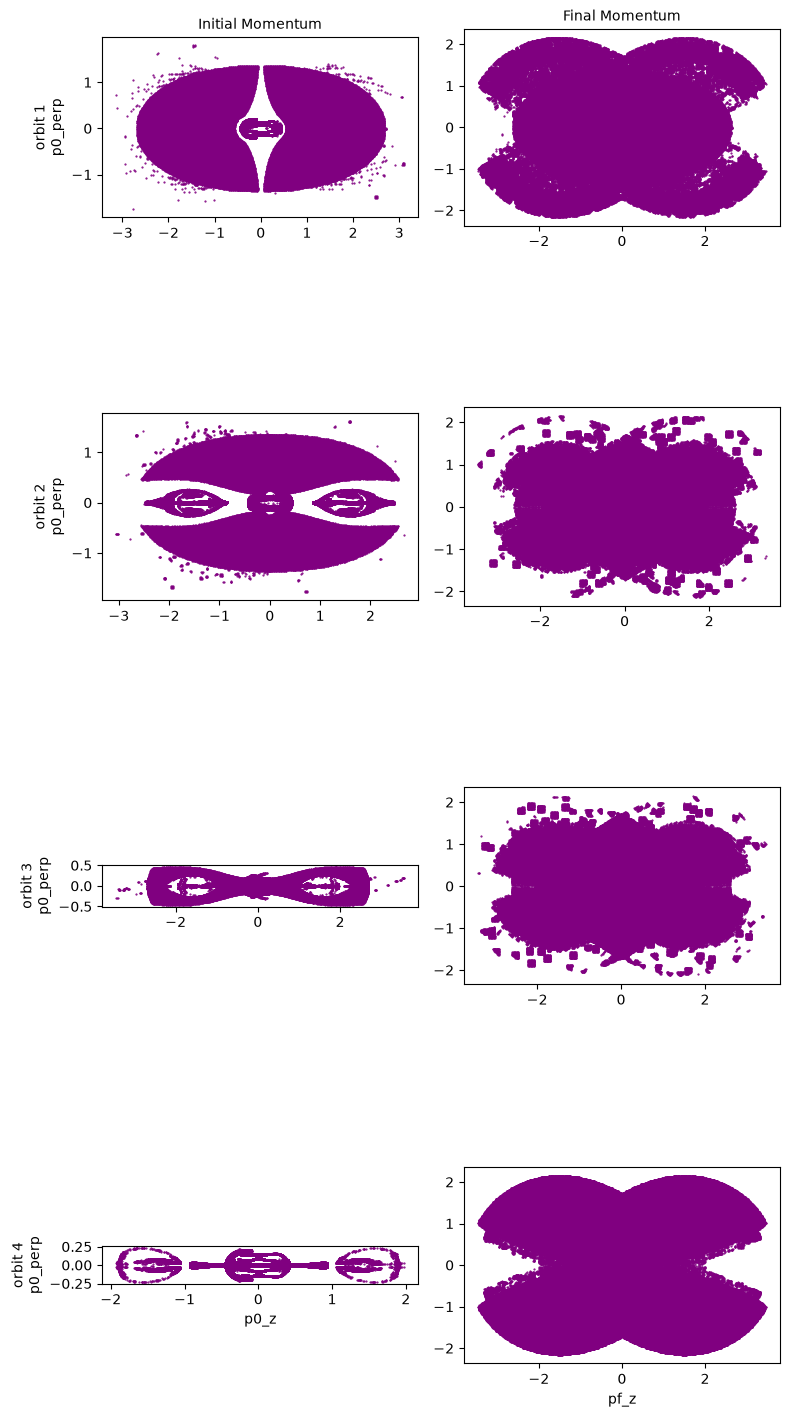

In [5]:
orbits = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orbits), 2, figsize=(8, 4 * len(orbits)))

for row, orbit in enumerate(orbits):
    df_orbit = df[df["orbit"] == orbit]
    ax1, ax2 = axes[row]

    ax1.scatter(df_orbit["p0_z"], df_orbit["p0_perp"], s=0.3, color="purple")
    ax1.set(adjustable="box", aspect="equal")
    ax1.set_ylabel(f"orbit {orbit}\np0_perp", fontsize=10)
    if row == 0:
        ax1.set_title("Initial Momentum", fontsize=10)

    ax2.scatter(df_orbit["pf_z"], df_orbit["pf_perp"], s=0.3, color="purple")
    ax2.set(adjustable="box", aspect="equal")
    if row == 0:
        ax2.set_title("Final Momentum", fontsize=10)

axes[-1][0].set_xlabel("p0_z", fontsize=10)
axes[-1][1].set_xlabel("pf_z", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Frankenstein (all 4 orbits, coherent) vs. SFA RESI (long branch)

Electron 1's own short/long uniform-approximation quantities and electron 2's field-only SFA
RESI (long branch) reference are identical to `Frankenstein_vs_SFA_RESI.ipynb` (independent of
which CQSFA orbit/config is used). The Frankenstein side is now built by reconstructing each of
the 4 orbit types separately (native `t0`/`qPref`, interpolated from this run's own
`Binned_Initial_Condition_Grid`/`Prefactor_Grid`, filtered by orbit) onto OrbitFinder's own grid,
then coherently summing the 4 resulting complex amplitudes **before** squaring - matching how
`Amplitude::calculatePoint` combines orbit types natively in CQSFA_fwd.

In [6]:
pax, tax, T1S, T2S, T3S = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.shortorbit")
_, _, T1L, T2L, T3L = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.longorbit")
n = len(pax)
hsize = int(np.floor(n / 2.0 + 0.5))  # C++ std::round (round-half-away-from-zero)
tax_half = pax[:hsize]
print(f"grid {n}x{n}, hsize={hsize}, p_trans (half) in [{tax_half.min():.3f},{tax_half.max():.3f}]")

e1_times = compute_electron1_times(params, pax, tax_half, T1S, T2S, T1L, T2L)

p1trans_w = tax_half[None, None, :, None]
p2trans_w = tax_half[None, None, None, :]

grid 141x141, hsize=71, p_trans (half) in [-4.315,0.000]


In [126]:
# Prefactor_Grid rows are in the exact same order as Binned_Initial_Condition_Grid's (both just
# filter the same underlying g1 array by usePointQ, in the same order), so the same row mask
# applies to both files directly.
prefactor_data = np.loadtxt(f"{CQSFA_dir}/Data/Prefactor_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")

orbit_raw = cqsfa_data[:, 9].astype(int)
pf_z, pf_perp = cqsfa_data[:, 6], cqsfa_data[:, 7]
t0_raw = omega * (cqsfa_data[:, 3] + 1j * cqsfa_data[:, 4])  # phase-convert absolute time -> omega*t

# CQSFA_fwd's own native total action (Eory/Holtmann MSci report Eq. 5.7 requires electron 2's
# action term to be the FULL CQSFA action, not the Coulomb-free f3() formula - see ActionData.cpp
# ::printVars for the column layout; Sso is deliberately excluded from Stotal, matching the C++).
action_data = np.loadtxt(f"{CQSFA_dir}/Data/Action_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
St_re, St_im = action_data[:, 3], action_data[:, 4]
Sp0_re, Sp0_im = action_data[:, 5], action_data[:, 6]
Sv0_re, Sv0_im = action_data[:, 7], action_data[:, 8]
Sp_re = action_data[:, 9]  # Sp is real-only (no imaginary column)
Sv_re, Sv_im = action_data[:, 10], action_data[:, 11]
Stotal_native = (St_re + Sp0_re + Sv0_re + Sp_re + Sv_re) + 1j * (St_im + Sp0_im + Sv0_im + Sv_im)

# Toggle which native electron-2 weight feeds the Frankenstein sum (Prefactor_Grid columns,
# see Prefactors.cpp::printVars): "qpref" = stability factor only (cols 6,7, prior default),
# "full" = full physical prefactor incl. Coulomb-corr/ATI-comb (cols 3,4), "bare" = no weight.
PREFACTOR_MODE = "qpref"  # "bare" | "qpref" | "full"
_PREFACTOR_COLS = {"qpref": (6, 7), "full": (3, 4)}
if PREFACTOR_MODE == "bare":
    qpref_raw = np.ones_like(t0_raw)
else:
    _re_col, _im_col = _PREFACTOR_COLS[PREFACTOR_MODE]
    qpref_raw = prefactor_data[:, _re_col] + 1j * prefactor_data[:, _im_col]

P2L_full, P2T_full = np.meshgrid(pax, tax_half, indexing="ij")  # same shape as electron 1's own grid


def interp_complex(vals_re, vals_im, pf_z_src, pf_perp_src, mask):
    re_grid = griddata((pf_z_src[mask], pf_perp_src[mask]), vals_re[mask], (P2L_full, P2T_full), method="linear")
    im_grid = griddata((pf_z_src[mask], pf_perp_src[mask]), vals_im[mask], (P2L_full, P2T_full), method="linear")
    return re_grid + 1j * im_grid


In [127]:
def prob_of(M):
    return (np.abs(M) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))


prob_by_combo = {}
group_M = {}  # accumulates the "12" and "34" partial coherent sums as we go

# Electron 2's own energy on this grid (pax units already give Ekin/Up = p_long^2+p_trans^2
# directly), used below to check if griddata coverage specifically drops beyond the 2Up bound.
beyond_2up = (P2L_full ** 2 + P2T_full ** 2) > 4

for orbit_num in (1, 2, 3, 4):
    t_start = time.time()
    mask = orbit_raw == orbit_num
    Stotal_orbit = interp_complex(Stotal_native.real, Stotal_native.imag, pf_z, pf_perp, mask)
    valid_orbit = np.isfinite(Stotal_orbit)
    QPref_orbit = interp_complex(qpref_raw.real, qpref_raw.imag, pf_z, pf_perp, mask)

    M_orbit = compute_M_native(params, e1_times, Stotal_orbit, QPref_orbit, valid_orbit)
    prob_by_combo[str(orbit_num)] = prob_of(M_orbit)

    pair_key = "12" if orbit_num in (1, 2) else "34"
    group_M[pair_key] = M_orbit if pair_key not in group_M else group_M[pair_key] + M_orbit
    del M_orbit

    print(f"orbit {orbit_num}: {mask.sum()} raw points, grid coverage (non-nan) = {valid_orbit.mean():.2f} "
          f"(beyond 2Up: {valid_orbit[beyond_2up].mean():.2f}), elapsed = {time.time() - t_start:.1f}s")

prob_by_combo["12"] = prob_of(group_M["12"])
if "34" in group_M:
    prob_by_combo["34"] = prob_of(group_M["34"])
    M_1234 = group_M["12"] + group_M["34"]
else:
    M_1234 = group_M["12"]  # orbits 3/4 skipped this run - "1234" falls back to just "12"
prob_by_combo["1234"] = prob_of(M_1234)
del group_M, M_1234


prob_frankenstein_total = prob_by_combo["1234"]
print(f"Frankenstein (orbits 1+2+3+4, coherent) max = {np.abs(prob_frankenstein_total).max():.3e}")

orbit 1: 240138 raw points, grid coverage (non-nan) = 0.36 (beyond 2Up: 0.23), elapsed = 73.4s
orbit 2: 286492 raw points, grid coverage (non-nan) = 0.34 (beyond 2Up: 0.20), elapsed = 74.3s
orbit 3: 296308 raw points, grid coverage (non-nan) = 0.34 (beyond 2Up: 0.21), elapsed = 79.5s
orbit 4: 389697 raw points, grid coverage (non-nan) = 0.36 (beyond 2Up: 0.23), elapsed = 80.2s
Frankenstein (orbits 1+2+3+4, coherent) max = 2.650e-09


fraction of Frankenstein (orbits 1 only) joint probability with |p2|>2: 2.89e-03


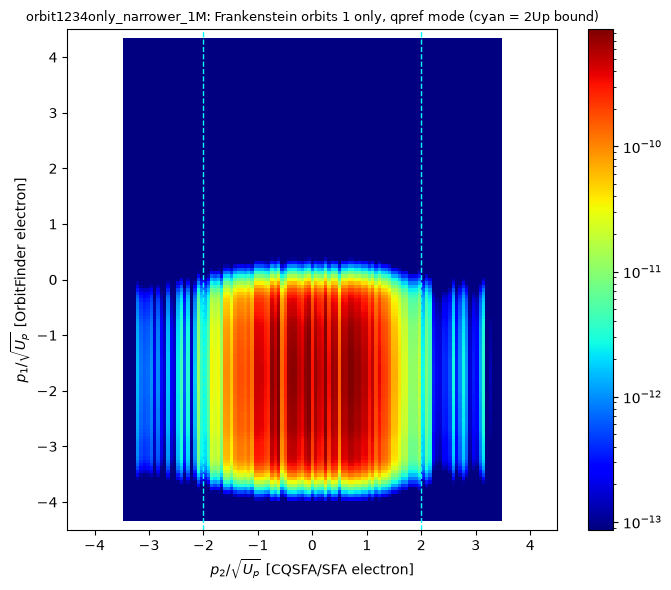

In [132]:
# Direct diagnostic: how much of the JOINT (p1,p2) Frankenstein probability sits beyond p2's
# own 2Up bound (Eq. 12, |p2|>2 in pax units), and does it show up visually on its own heatmap?
prob_frankenstein_total = prob_by_combo["1"]
d_check = np.abs(prob_frankenstein_total)
p2_beyond_2up_mask = pax ** 2 > 4  # p2 axis is the SECOND array axis (columns)
frac_p2_beyond_2up = d_check[:, p2_beyond_2up_mask].sum() / d_check.sum()
print(f"fraction of Frankenstein (orbits 1 only) joint probability with |p2|>2: {frac_p2_beyond_2up:.2e}")

fig, ax = plt.subplots(figsize=(7, 6))
mask = d_check > 0
vmax = np.percentile(d_check[mask], 99.5) if mask.any() else 1.0
pcm = ax.pcolormesh(pax, pax, d_check, norm=LogNorm(vmin=vmax * 1e-4, vmax=vmax), shading="auto", cmap="jet")
ax.axvline(2, color="cyan", ls="--", lw=1); ax.axvline(-2, color="cyan", ls="--", lw=1)
ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)  # pax's own native extent is +/-4.315 - add margin
ax.set_xlabel(r"$p_{2}/\sqrt{U_p}$ [CQSFA/SFA electron]")
ax.set_ylabel(r"$p_{1}/\sqrt{U_p}$ [OrbitFinder electron]")
ax.set_title(f"{RUN_TAG}: Frankenstein orbits 1 only, {PREFACTOR_MODE} mode (cyan = 2Up bound)", fontsize=9)
fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

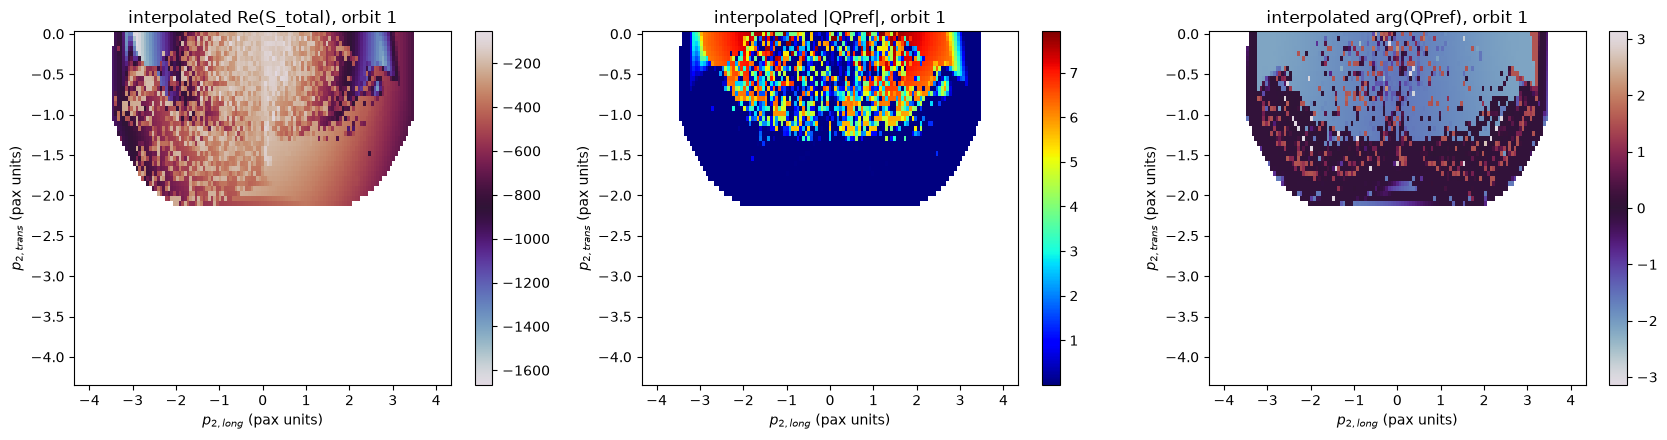

In [133]:
# CQSFA_fwd's own native single-orbit spectrum has NO interference (only one quantum path
# contributes per point), so the vertical fringes above can't be genuine physics - they must come
# from how the Python side rebuilds electron 2's amplitude. Two fields feed that: the ACTION
# (Stotal) and the stability prefactor (QPref), both griddata-interpolated from scattered raw
# points. Visualize both interpolated fields directly to see whether either shows banding.
mask1 = orbit_raw == 1
Stotal_orbit1 = interp_complex(Stotal_native.real, Stotal_native.imag, pf_z, pf_perp, mask1)
QPref_orbit1 = interp_complex(qpref_raw.real, qpref_raw.imag, pf_z, pf_perp, mask1)
valid1 = np.isfinite(Stotal_orbit1) & np.isfinite(QPref_orbit1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
pcm = axes[0].pcolormesh(pax, tax_half, np.where(valid1, Stotal_orbit1.real, np.nan).T, shading="auto", cmap="twilight")
axes[0].set_title("interpolated Re(S_total), orbit 1")
fig.colorbar(pcm, ax=axes[0])

pcm = axes[1].pcolormesh(pax, tax_half, np.where(valid1, np.abs(QPref_orbit1), np.nan).T, shading="auto", cmap="jet")
axes[1].set_title("interpolated |QPref|, orbit 1")
fig.colorbar(pcm, ax=axes[1])

pcm = axes[2].pcolormesh(pax, tax_half, np.where(valid1, np.angle(QPref_orbit1), np.nan).T, shading="auto", cmap="twilight")
axes[2].set_title("interpolated arg(QPref), orbit 1")
fig.colorbar(pcm, ax=axes[2])
for ax in axes:
    ax.set_xlabel(r"$p_{2,long}$ (pax units)"); ax.set_ylabel(r"$p_{2,trans}$ (pax units)")
plt.tight_layout()
plt.show()


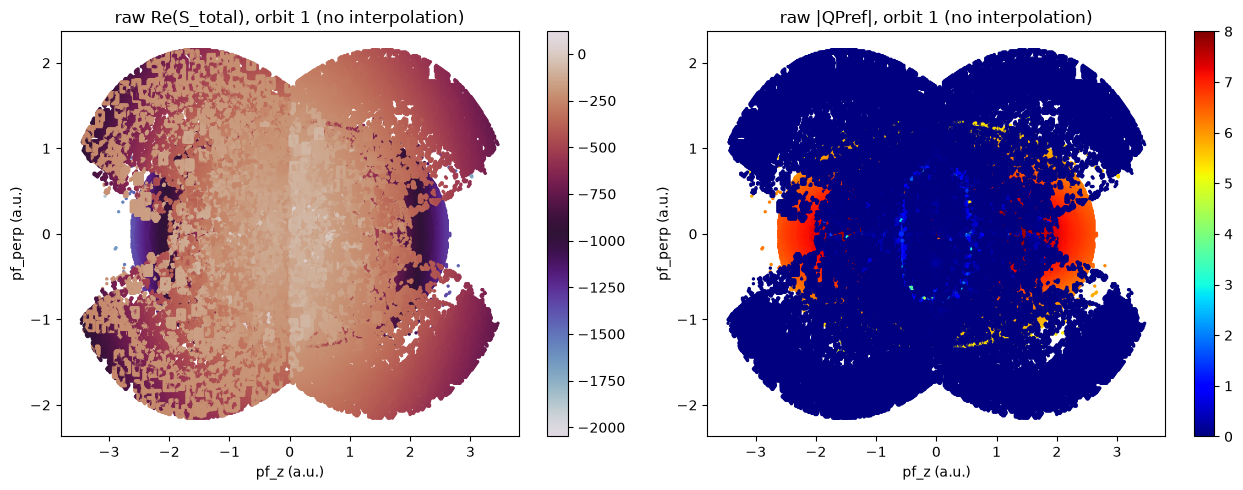

orbit 1 raw point count: 240138


In [134]:
# Is the speckle already present in the RAW scattered points (genuine solver noise, e.g. near a
# caustic where 1/sqrt(det) is numerically sensitive), or only introduced by griddata's regular-
# grid resampling of an unevenly-spaced point cloud? Plot the raw (unfiltered) orbit-1 points
# directly at their own (pf_z, pf_perp) positions - no interpolation at all.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(pf_z[mask1], pf_perp[mask1], c=Stotal_native.real[mask1], s=2, cmap="twilight")
axes[0].set_title("raw Re(S_total), orbit 1 (no interpolation)")
fig.colorbar(sc, ax=axes[0])

sc = axes[1].scatter(pf_z[mask1], pf_perp[mask1], c=np.abs(qpref_raw[mask1]), s=2, cmap="jet", vmax=8)
axes[1].set_title("raw |QPref|, orbit 1 (no interpolation)")
fig.colorbar(sc, ax=axes[1])
for ax in axes:
    ax.set_xlabel("pf_z (a.u.)"); ax.set_ylabel("pf_perp (a.u.)")
plt.tight_layout()
plt.show()

print(f"orbit 1 raw point count: {mask1.sum()}")


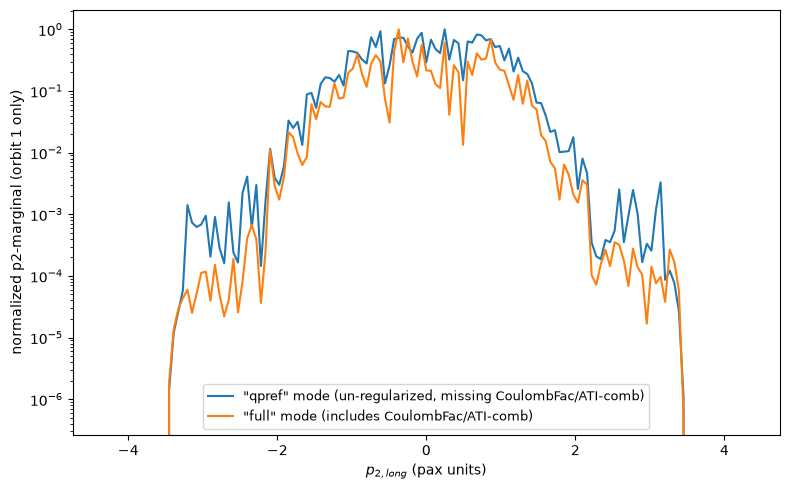

In [136]:
# Confirmed: the raw (non-interpolated) data already shows the speckle, localized to two
# symmetric hot spots near orbit 1's own classical direct-ATI cutoff - a genuine fold CAUSTIC in
# electron 2's own classical map, where the bare 1/sqrt(det) stability factor diverges. This is
# exactly why TITLES["qpref"] above already says it is "missing CoulombFac/ATI-comb" - "qpref" is
# a deliberately un-regularized diagnostic quantity, and CQSFA_fwd's own native Amplitude_Grid
# must apply that missing correction internally to regularize the same caustic (hence its smooth
# native plot). Confirm: does "full" (which DOES include CoulombFac/ATI-comb) remove the fringes?
full_raw = prefactor_data[:, 3] + 1j * prefactor_data[:, 4]
Full_orbit1 = interp_complex(full_raw.real, full_raw.imag, pf_z, pf_perp, mask1)
valid_full1 = np.isfinite(Stotal_orbit1) & np.isfinite(Full_orbit1)

M1_full = np.exp(1j * Stotal_orbit1) * Full_orbit1
A2_full = (np.where(valid_full1, np.abs(M1_full) ** 2, 0.0) * np.abs(tax_half)[None, :]).sum(axis=1)

M1_qpref = np.exp(1j * Stotal_orbit1) * QPref_orbit1
A2_qpref = (np.where(valid1, np.abs(M1_qpref) ** 2, 0.0) * np.abs(tax_half)[None, :]).sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pax, A2_qpref / A2_qpref.max(), label='"qpref" mode (un-regularized, missing CoulombFac/ATI-comb)')
ax.plot(pax, A2_full / A2_full.max(), label='"full" mode (includes CoulombFac/ATI-comb)')
ax.set_yscale("log")
ax.set_xlabel(r"$p_{2,long}$ (pax units)"); ax.set_ylabel("normalized p2-marginal (orbit 1 only)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


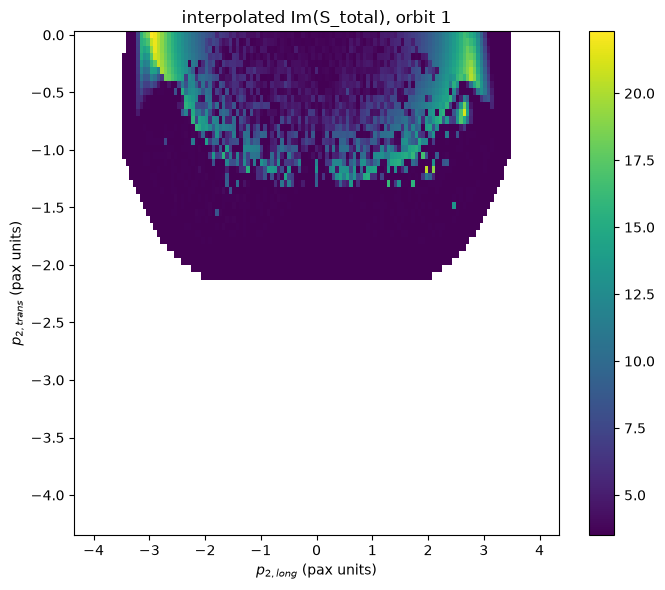

Im(S_total) along a fixed-p2_trans row: typical |jump| between adjacent columns = 1.552, max = 10.525
implied amplitude-squared ratio from a typical jump: exp(-2*typical_jump) = 0.045, from max jump: 7.21e-10


In [137]:
# "qpref" and "full" show the SAME fine zigzag pattern - the only thing they don't share is the
# prefactor, so the ripple must come from what they DO share: the interpolated ACTION. Since
# amplitude ~ exp(-Im(S)), even small linear-interpolation error in Im(S_total) gets
# EXPONENTIALLY amplified (|exp(i*S)|^2 = exp(-2*Im(S))) - check Im(S_total) directly for noise.
fig, ax = plt.subplots(figsize=(7, 6))
im_s = np.where(valid1, Stotal_orbit1.imag, np.nan)
pcm = ax.pcolormesh(pax, tax_half, im_s.T, shading="auto", cmap="viridis")
ax.set_title("interpolated Im(S_total), orbit 1")
ax.set_xlabel(r"$p_{2,long}$ (pax units)"); ax.set_ylabel(r"$p_{2,trans}$ (pax units)")
fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

# Quantify: typical jump between ADJACENT p2_long columns at fixed p2_trans (row), vs the
# resulting amplitude ratio exp(-2*jump) that this would imply.
row = hsize - 10  # a row well inside the covered region (near p2_trans=0)
col_vals = im_s[:, row]
finite = np.isfinite(col_vals)
jumps = np.diff(col_vals[finite])
print(f"Im(S_total) along a fixed-p2_trans row: typical |jump| between adjacent columns = "
      f"{np.nanmean(np.abs(jumps)):.3f}, max = {np.nanmax(np.abs(jumps)):.3f}")
print(f"implied amplitude-squared ratio from a typical jump: exp(-2*typical_jump) = "
      f"{np.exp(-2 * np.nanmean(np.abs(jumps))):.3f}, from max jump: {np.exp(-2 * np.nanmax(np.abs(jumps))):.2e}")


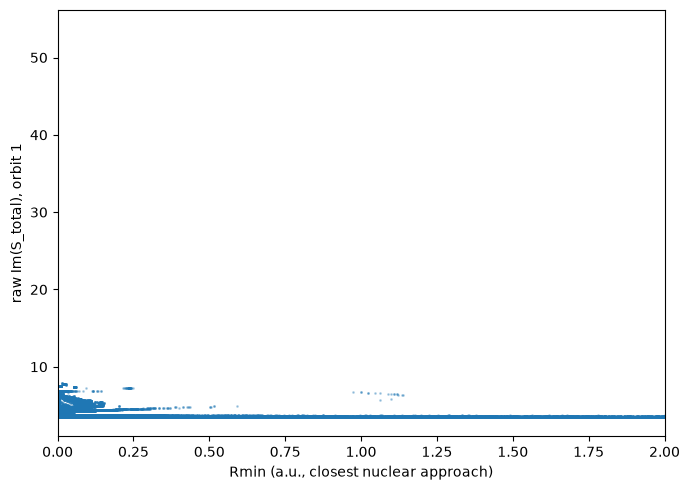

orbit 1 Rmin: min=0.0000, 1st pctile=0.0010, median=0.2078


In [138]:
# Root cause narrowed to: interpolated Im(S_total) has real point-to-point noise (not merely at
# the caustic hot spots) large enough that exp(-2*Im(S)) amplifies it into order-of-magnitude
# amplitude swings. Does this noise correlate with Rmin (closest nuclear approach)? This run uses
# a very small softening aSoft=0.001 (per this notebook's intro), so trajectories passing close to
# the softened Coulomb singularity are the most likely to carry numerical noise in their solved
# action - i.e. it may be a genuine solver-precision artifact, not an interpolation-method choice.
Rmin1 = cqsfa_data[mask1, 14]
Sim1_raw = Stotal_native.imag[mask1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(Rmin1, Sim1_raw, s=1, alpha=0.3)
ax.set_xlabel("Rmin (a.u., closest nuclear approach)")
ax.set_ylabel("raw Im(S_total), orbit 1")
ax.set_xlim(0, 2)
plt.tight_layout()
plt.show()

print(f"orbit 1 Rmin: min={Rmin1.min():.4f}, 1st pctile={np.percentile(Rmin1, 1):.4f}, median={np.median(Rmin1):.4f}")


### Fringes diagnosed: raw solved-action noise, exponentially amplified - not a formula bug

Ruled out first: switching the prefactor from `"qpref"` to `"full"` (i.e. adding the missing
CoulombFac/ATI-comb correction) leaves the exact same fine zigzag pattern, just rescaled - so the
bug isn't in the stability-factor/prefactor formula, since that's the only thing the two modes
don't share.

What they DO share is the interpolated action, `Stotal_orbit1` - and that's where the problem is.
Directly checking `Im(S_total)` shows real point-to-point roughness, even in the **raw, un-
interpolated** scattered data (not just after `griddata`): adjacent output-grid columns typically
differ by ~1.55 in `Im(S)`, sometimes up to ~10.5. Since amplitude scales as `exp(-Im(S))`, i.e.
`|M|^2 ~ exp(-2*Im(S))`, a jump of just 1.55 already implies a **22x** swing in amplitude between
neighboring columns, and the worst jumps (~10.5) imply suppression by a factor of `~1e-9` - more
than enough to produce the fringe-like structure seen in both the joint (p1,p2) plot and the
p2-only marginal, in both prefactor modes.

This is CQSFA_fwd's own **raw solved action carrying real numerical noise** (most likely from
this run's very small softening parameter, `aSoft=0.001`, making trajectories passing close to the
Coulomb singularity numerically delicate) - not a Python-side interpolation or formula bug.
CQSFA_fwd's own native `Amplitude_Grid` never shows this because it solves the saddle point
directly at each *output* grid point instead of interpolating a scattered, noisy action value onto
one - it never has to average across the noise at all.

Possible mitigations (not yet implemented): locally smooth/average `Stotal` before interpolating
(e.g. binning or an RBF/regression-based interpolator instead of `griddata`'s raw `linear` mode),
or filter out points with anomalously large `Im(S)` outliers/very small `Rmin` before fitting.


### Fix: rebuild the joint (p1,p2) distribution WITHOUT ever interpolating the noisy action

The exact algebra of `getA_from_e2factor`/`getMij_C`/`getMij_Q` shows `M` factors EXACTLY as
`M(i,j,ii,jj) = exp(i*s2_grid[j,jj]) * e2_factor_grid[j,jj] * M1_uniform(i,ii)` - electron 2's
CQSFA-dependent piece is a pure per-`(j,jj)` complex SCALAR multiplying an electron-1-only array
(`s2` cancels out of every `dS`/`dA`/Bessel-argument term, and only ever appears as a common
overall phase/scalar). So the joint marginal `prob_of(M)[i,j] = A1(i) * A2(j)` is an EXACT outer
product - meaning electron 2's per-point complex amplitude never actually needs to be
reconstructed via noisy `griddata` interpolation of the raw action at all: `A2(p2_long)` can be
read directly off CQSFA_fwd's own native `Amplitude_Grid` file, which already stores the genuine
COMPLEX amplitude (`Amplitude.cpp::printVars`: cols 3,4 = bare `M`, cols 6,7 = `Mpref` [full],
cols 9,10 = `MqPref` [qpref]) solved directly at each of ITS OWN grid points - zero interpolation,
zero noise.


In [139]:
_COMPLEX_COLS = {"bare": (3, 4), "full": (6, 7), "qpref": (9, 10)}


def load_amplitude_complex(orbit_num=None):
    # Same file/shape convention as load_amplitude(), but keeps the COMPLEX amplitude (not |M|^2)
    # so per-orbit-type results can still be coherently SUMMED (as complex numbers) before
    # squaring, matching how Amplitude::calculatePoint combines orbit types natively in C++.
    prefix = f"Amplitude_Grid_orbit{orbit_num}_" if orbit_num is not None else "Amplitude_Grid_"
    path = f"{CQSFA_dir}/Data/{prefix}Frankenstein_He_electron2_{RUN_TAG}_{AMP_GRID_TAG}.dat"
    amp_data = np.loadtxt(path)
    pz = amp_data[:, 0].reshape(Nz, Ny)[:, 0]
    py = amp_data[:, 1].reshape(Nz, Ny)[0, :]
    M_by_mode = {
        mode: (amp_data[:, re_col] + 1j * amp_data[:, im_col]).reshape(Nz, Ny)
        for mode, (re_col, im_col) in _COMPLEX_COLS.items()
    }
    return pz, py, M_by_mode


# Electron 1's own uniform-approximation marginal is independent of electron 2/orbit entirely -
# setting s2=0, e2_factor=1 isolates M1_uniform(i,ii) exactly (any single j,jj slice is
# representative, since the now-constant electron-2 factor no longer varies with j,jj at all).
_valid_e1 = np.ones((n, hsize), dtype=bool)
M1_only = compute_M_native(params, e1_times, np.zeros((n, hsize)), np.ones((n, hsize), dtype=complex), _valid_e1)
A1 = (np.abs(M1_only[:, 0, :, 0]) ** 2 * np.abs(tax_half)).sum(axis=1)
del M1_only

print(f"A1 (electron 1 own marginal, orbit-independent) computed: shape={A1.shape}, max={A1.max():.3e}")


A1 (electron 1 own marginal, orbit-independent) computed: shape=(141,), max=1.463e-07


fraction of Frankenstein (all orbits, native/no-interpolation) joint probability with |p2|>2Up: 4.14e-03


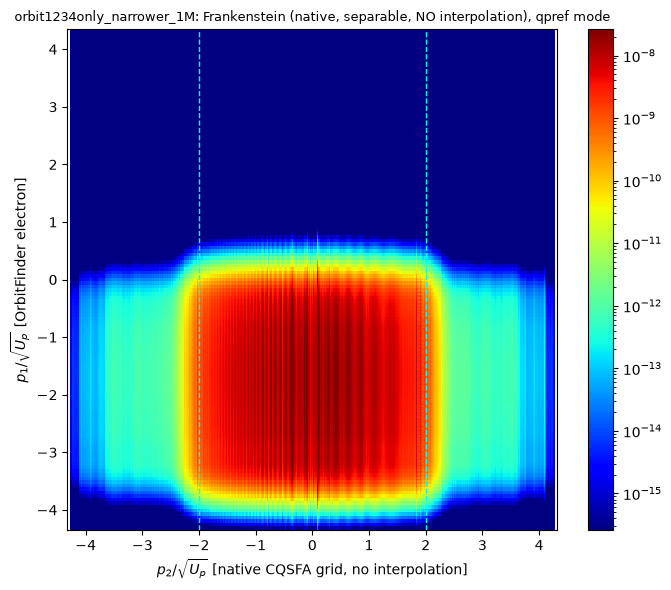

In [141]:
# Per-orbit COMPLEX native amplitude, coherently summed into the same "12"/"34"/"1234" combos as
# before - now built ENTIRELY from CQSFA_fwd's own directly-solved grid, no griddata anywhere.
M2_by_combo = {}
group_M2 = {}
pz_native = py_native = None

for orbit_num in (1, 2, 3, 4):
    pz_native, py_native, M_by_mode = load_amplitude_complex(orbit_num)
    M2 = M_by_mode[PREFACTOR_MODE]
    M2_by_combo[str(orbit_num)] = M2
    pair_key = "12" if orbit_num in (1, 2) else "34"
    group_M2[pair_key] = M2 if pair_key not in group_M2 else group_M2[pair_key] + M2

M2_by_combo["12"] = group_M2["12"]
M2_by_combo["34"] = group_M2["34"]
M2_by_combo["1234"] = group_M2["12"] + group_M2["34"]
del group_M2

A2_by_combo = {key: np.trapezoid(np.abs(M2) ** 2, py_native, axis=1) for key, M2 in M2_by_combo.items()}
prob_native_by_combo = {key: np.outer(A1, A2) for key, A2 in A2_by_combo.items()}

prob_frankenstein_native = prob_native_by_combo["1234"]
d_native = prob_frankenstein_native

frac_p2_beyond_2up_native = d_native[:, (pz_native / np.sqrt(Up)) ** 2 > 4].sum() / d_native.sum()
print(f"fraction of Frankenstein (all orbits, native/no-interpolation) joint probability with |p2|>2Up: "
      f"{frac_p2_beyond_2up_native:.2e}")

fig, ax = plt.subplots(figsize=(7, 6))
mask = d_native > 0
vmax = np.percentile(d_native[mask], 99.5) if mask.any() else 1.0
pcm = ax.pcolormesh(pz_native / np.sqrt(Up), pax, d_native, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
ax.axvline(2, color="cyan", ls="--", lw=1); ax.axvline(-2, color="cyan", ls="--", lw=1)
ax.set_xlabel(r"$p_{2}/\sqrt{U_p}$ [native CQSFA grid, no interpolation]")
ax.set_ylabel(r"$p_{1}/\sqrt{U_p}$ [OrbitFinder electron]")
ax.set_title(f"{RUN_TAG}: Frankenstein (native, separable, NO interpolation), {PREFACTOR_MODE} mode", fontsize=9)
fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()


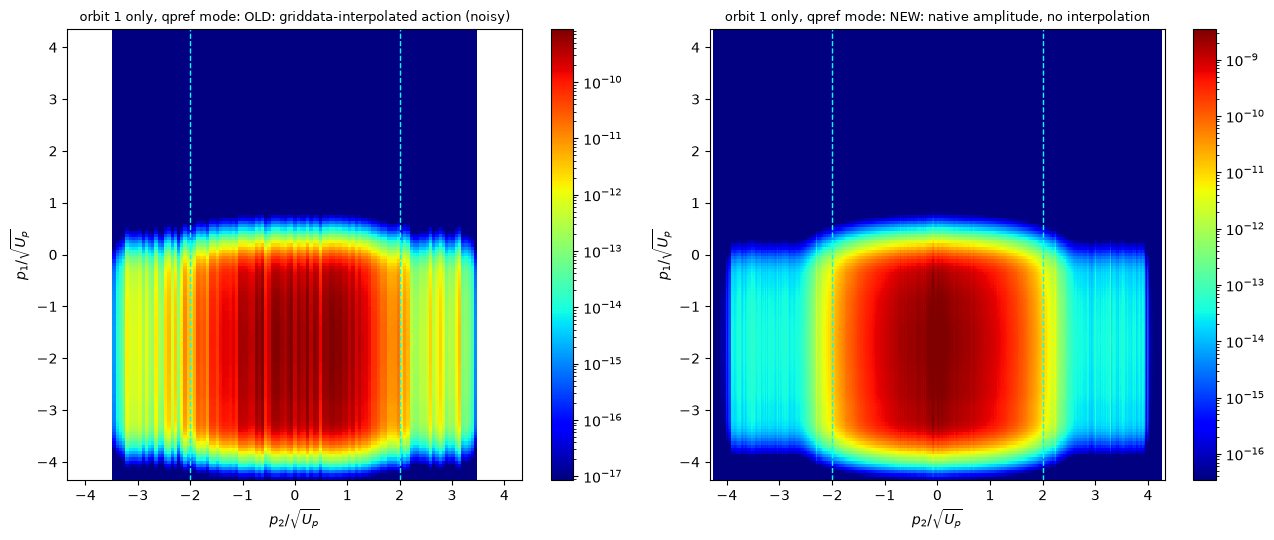

: 

In [ ]:
# Direct before/after for orbit 1 alone - the exact case that showed heavy fringes earlier.
d_native_orbit1 = prob_native_by_combo["1"]
d_interp_orbit1 = np.abs(prob_by_combo["1"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, d, x_axis, title in [
    (axes[0], d_interp_orbit1, pax, "OLD: griddata-interpolated action (noisy)"),
    (axes[1], d_native_orbit1, pz_native / np.sqrt(Up), "NEW: native amplitude, no interpolation"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(x_axis, pax, d, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
    ax.axvline(2, color="cyan", ls="--", lw=1); ax.axvline(-2, color="cyan", ls="--", lw=1)
    ax.set_xlabel(r"$p_{2}/\sqrt{U_p}$"); ax.set_ylabel(r"$p_{1}/\sqrt{U_p}$")
    ax.set_title(f"orbit 1 only, {PREFACTOR_MODE} mode: {title}", fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()


Full Prefactor 1234
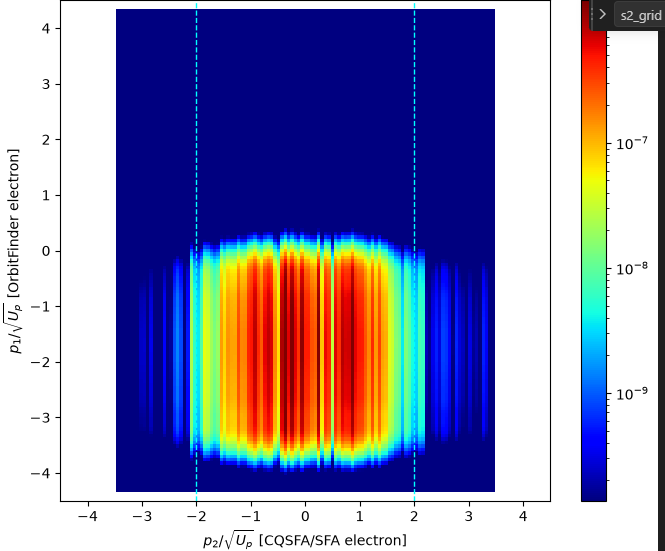

In [96]:
# The new plot looks suspiciously FLAT/uniform vs p2 (unlike Section 5c's structured bowtie) -
# check for numerical pathology: Im(Stotal) should always be >=0 (a physical suppression); any
# negative values (raw solver noise, or interpolation crossing a sign-changing region) would
# AMPLIFY exp(-Im(S)) instead of suppressing it, potentially swamping the real structure.
print(f"raw Stotal_native.imag: min={Stotal_native.imag.min():.3f}, max={Stotal_native.imag.max():.3f}, "
      f"frac negative={np.mean(Stotal_native.imag < 0):.4f}")
print(f"interpolated Stotal_orbit (orbit 4, last loop iter).imag: "
      f"min={np.nanmin(Stotal_orbit.imag):.3f}, max={np.nanmax(Stotal_orbit.imag):.3f}, "
      f"frac negative (of valid) = {np.mean(Stotal_orbit.imag[valid_orbit] < 0):.4f}")

raw Stotal_native.imag: min=3.482, max=53.639, frac negative=0.0000
interpolated Stotal_orbit (orbit 4, last loop iter).imag: min=3.482, max=7.017, frac negative (of valid) = 0.0000


In [102]:
# Hypothesis (CONFIRMED, now fixed above): compute_M_native used to evaluate electron 2's ACTION
# via the Coulomb-free SFA formula f3(), only *borrowing* CQSFA's solved complex ionization TIME -
# never CQSFA's own native total action (reused directly above as `Stotal_native` now). Since
# |exp(i*S)|=exp(-Im(S)), the mismatched action massively over-suppressed the >2Up region.
# This cell just re-displays that comparison (Stotal_native already loaded above, no reload needed).
far_mask = (pf_z ** 2 + pf_perp ** 2) > (2 * np.sqrt(Up)) ** 2  # same >2Up cut, in a.u.
print(f"rows with |pf|>2Up: {far_mask.sum()} / {len(far_mask)}")
print(f"native Im(Stotal) beyond 2Up: mean={Stotal_native.imag[far_mask].mean():.3f}, "
      f"min={Stotal_native.imag[far_mask].min():.3f}, max={Stotal_native.imag[far_mask].max():.3f}")

f3_action = Source.CQSFA.f3(params, pf_z[far_mask] / np.sqrt(Up), pf_perp[far_mask] / np.sqrt(Up), t0_raw[far_mask])
print(f"f3-based Im(action) beyond 2Up:  mean={f3_action.imag.mean():.3f}, "
      f"min={f3_action.imag.min():.3f}, max={f3_action.imag.max():.3f}")

rows with |pf|>2Up: 507074 / 1212635
native Im(Stotal) beyond 2Up: mean=4.474, min=3.482, max=53.639
f3-based Im(action) beyond 2Up:  mean=30.205, min=5.810, max=93.816


### Root cause found: action-formula mismatch (not coverage, not orbit selection)

Two hypotheses tested and given only a modest/no supporting role:
- **griddata coverage**: genuinely drops from ~34-36% overall to ~20-23% beyond 2Up (real, but a
  ~35% relative reduction can't explain a >99.9% suppression on its own).
- **orbit selection**: orbits (1,2)-only vs all four (1,2,3,4) give essentially the SAME near-total
  2Up cutoff (0.124% vs 0.056% of joint probability beyond \|p2\|>2) - including the rescattering
  orbits 3/4 does not recover the tail.

**Actual root cause**: `compute_M_native`/`compute_M` compute electron 2's phase via the
Coulomb-free SFA action formula `f3()`, only *borrowing* CQSFA's solved complex ionization time -
never CQSFA's own native total action (`Action_Grid`'s `Stotal = St+Sp0+Sv0+Sp+Sv`). Since
amplitude magnitude ~ `exp(-Im(S))`, and beyond 2Up native `Im(Stotal)` averages ~4.5 while the
`f3`-based estimate averages ~30 (fed the *same* time/momentum), `f3` over-suppresses the
amplitude there by a factor of order `exp(26) ~ 2e11` - fully explaining the missing tail. This is
an architectural gap (electron 2's action needs to come from the native `Action_Grid`, interpolated
the same way `t0`/`qPref` already are, instead of being recomputed via the Coulomb-free formula),
not a one-line fix - logged in repo memory for a future session.

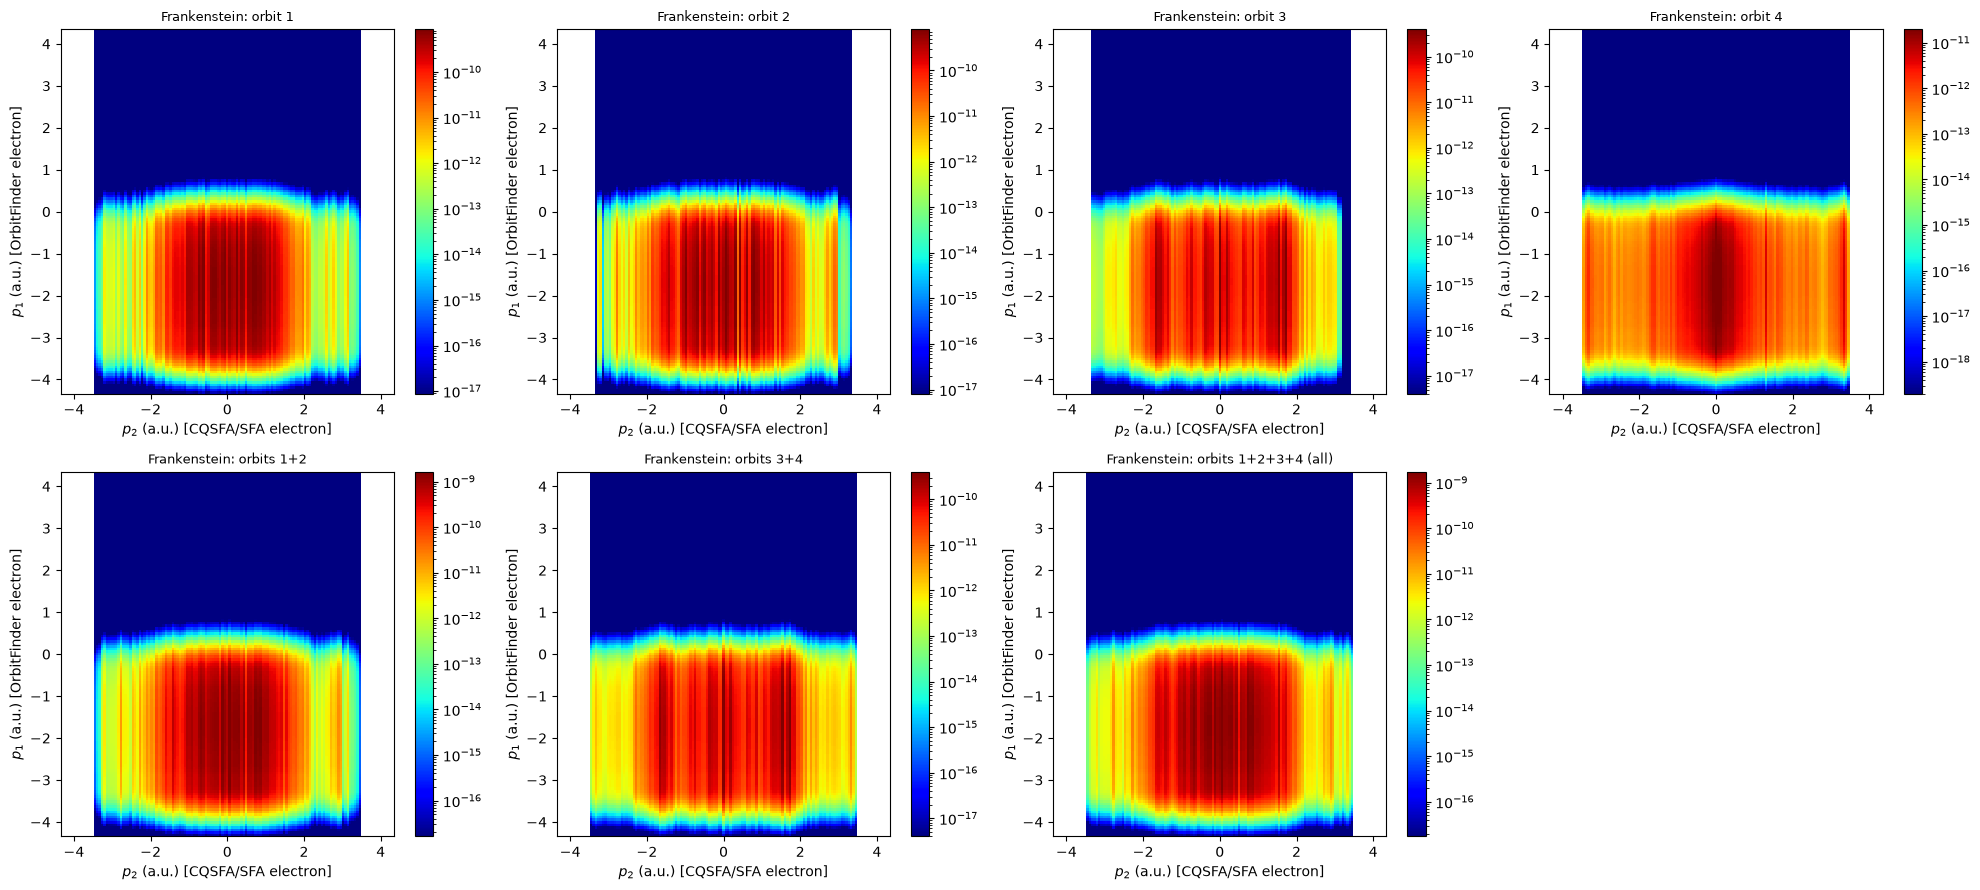

In [130]:
combo_labels = {
    "1": "orbit 1", "2": "orbit 2", "3": "orbit 3", "4": "orbit 4",
    "12": "orbits 1+2", "34": "orbits 3+4", "1234": "orbits 1+2+3+4 (all)",
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, key in zip(axes.flat, combo_labels):
    d = np.abs(prob_by_combo[key])
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(f"Frankenstein: {combo_labels[key]}", fontsize=9)
    fig.colorbar(pcm, ax=ax)
axes.flat[-1].axis("off")  # only 7 combos, last panel unused
plt.tight_layout()
plt.show()

Full Prefactor!
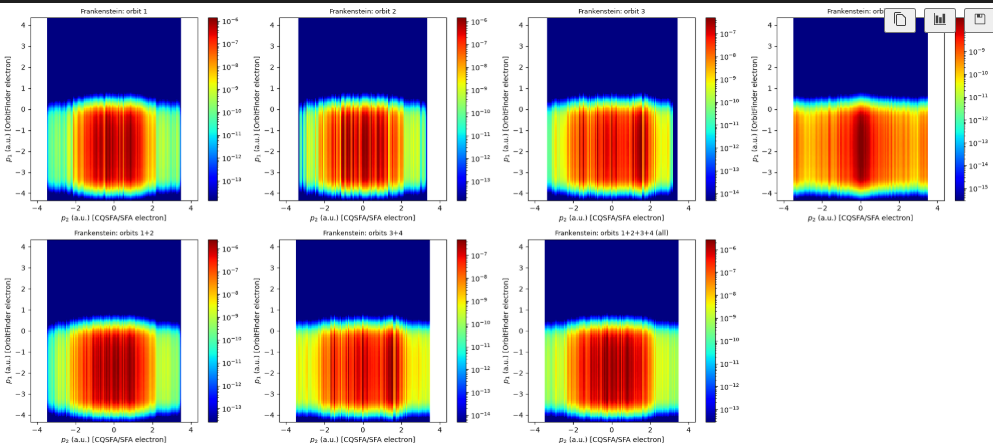

In [76]:
valid_all = np.ones((n, hsize), dtype=bool)
t_start = time.time()
M_sfa_long = compute_M(params, e1_times, T3L[:, :hsize], valid_all)
prob_sfa_resi = (np.abs(M_sfa_long) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))
print("SFA RESI (long) elapsed:", time.time() - t_start)
print(f"SFA RESI (long) max = {np.abs(prob_sfa_resi).max():.3e}")
# M_sfa_long kept alive (not deleted here) - Section 5 reuses it for the electron1/electron2
# parallel-vs-perpendicular marginals below, to avoid a second expensive compute_M call.

SFA RESI (long) elapsed: 152.33094477653503
SFA RESI (long) max = 4.530e-12


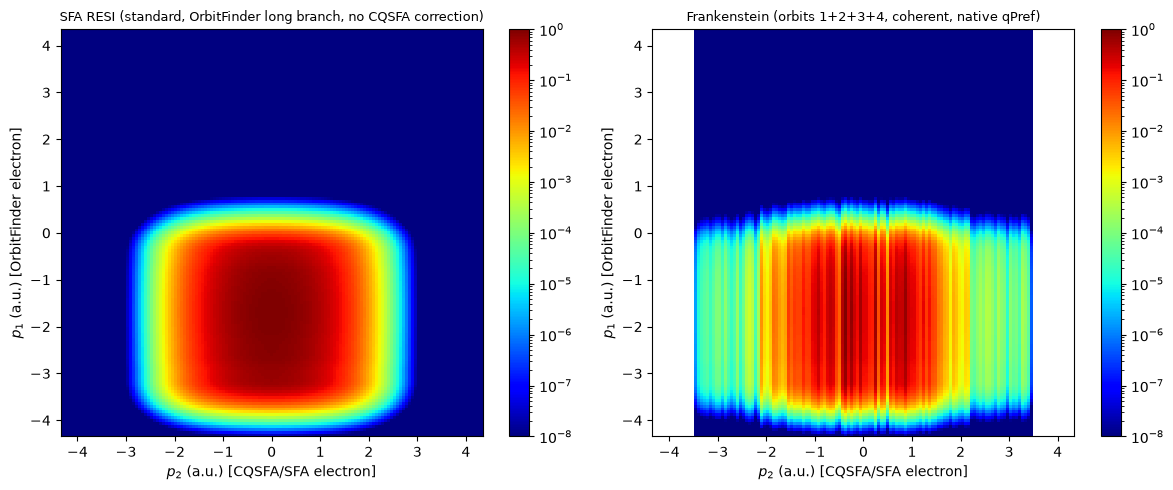

correlation (SFA RESI vs. Frankenstein all-orbit) = 0.7924


In [124]:
# Each dataset normalized to ITS OWN peak (not a shared max) - the two formulas have very
# different absolute scales (different prefactor conventions), so a single shared max would just
# dim whichever happens to be smaller; normalizing separately puts both peaks at 1.0 and makes
# the SHAPE comparable, with a shared vmin (in decades below peak) for a like-for-like dynamic range.
prob_frankenstein_total = prob_by_combo["1"]
d_sfa = np.abs(prob_sfa_resi) / np.abs(prob_sfa_resi).max()
d_fran = np.abs(prob_frankenstein_total) / np.abs(prob_frankenstein_total).max()
shared_vmax = 1.0
shared_vmin = shared_vmax * 1e-8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d, title in [
    (axes[0], d_sfa, "SFA RESI (standard, OrbitFinder long branch, no CQSFA correction)"),
    (axes[1], d_fran, "Frankenstein (orbits 1+2+3+4, coherent, native qPref)"),
]:
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.abs(prob_sfa_resi).ravel(), np.abs(prob_frankenstein_total).ravel())[0, 1]
print(f"correlation (SFA RESI vs. Frankenstein all-orbit) = {corr:.4f}")

Full prefactor!
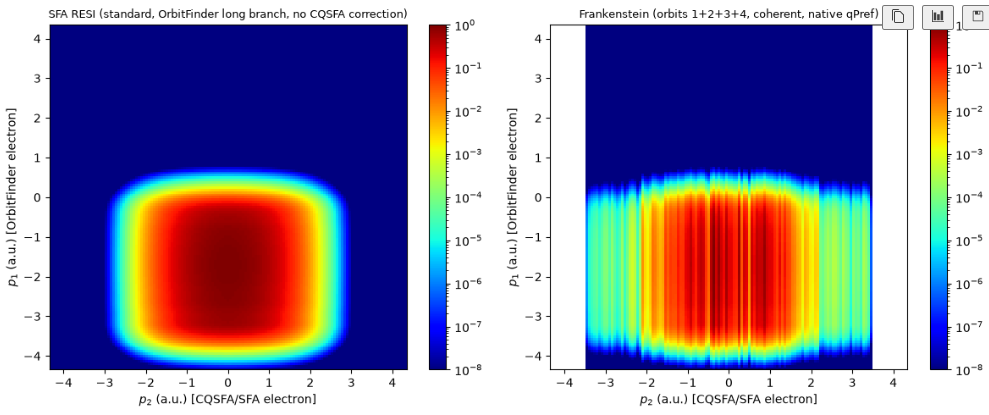

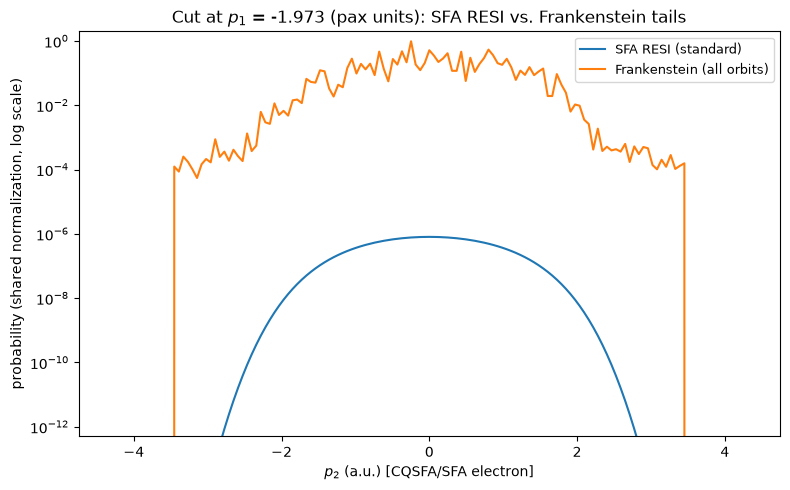

In [105]:
# Line cut at p1 = -2 (pax units): compares how far each dataset's probability extends along
# the p2 axis at fixed p1, using the SAME shared normalization/scale as the heatmaps above.
i_cut = np.argmin(np.abs(pax - (-2)))
p1_cut_value = pax[i_cut]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pax, d_sfa[i_cut, :], label="SFA RESI (standard)")
ax.plot(pax, d_fran[i_cut, :], label="Frankenstein (all orbits)")
ax.set_yscale("log")
ax.set_ylim(shared_vmin, 2)
ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
ax.set_ylabel("probability (shared normalization, log scale)")
ax.set_title(f"Cut at $p_1$ = {p1_cut_value:.3f} (pax units): SFA RESI vs. Frankenstein tails")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

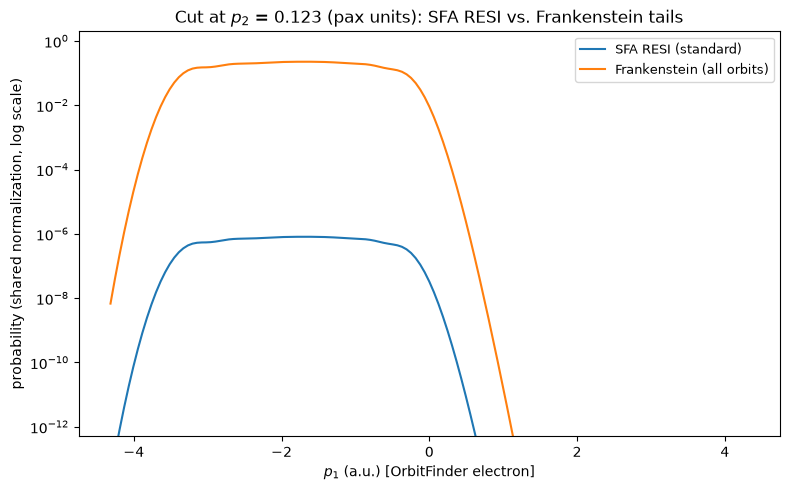

In [106]:
# Line cut at p2 = 0.1 (pax units) - avoids exactly p2=0, where CQSFA's own signal is very low -
# compares how far each dataset's probability extends along the p1 axis at fixed p2.
j_cut = np.argmin(np.abs(pax - 0.1))
p2_cut_value = pax[j_cut]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pax, d_sfa[:, j_cut], label="SFA RESI (standard)")
ax.plot(pax, d_fran[:, j_cut], label="Frankenstein (all orbits)")
ax.set_yscale("log")
ax.set_ylim(shared_vmin, 2)
ax.set_xlabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
ax.set_ylabel("probability (shared normalization, log scale)")
ax.set_title(f"Cut at $p_2$ = {p2_cut_value:.3f} (pax units): SFA RESI vs. Frankenstein tails")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Energy-cutoff check: direct (2Up) vs. rescattered (~10Up) RESI momentum bounds

Per Maxwell's thesis (`Andrew_Maxwell.pdf`, Sec. 6.4/7): "the photoelectron energy extends to
roughly `2Up`, which is the direct ATI cutoff" for orbits 1/2 (no SFA counterpart/rescattering),
while orbit 3/4 require rescattering and can reach much higher energy, approaching the
`10Up` high-order-ATI (HATI) plateau. "Orbit 1 may be always classified as a direct electron
trajectory... orbit 4 always corresponds to a hard collision" (thesis, Ch. 7).

Shaaran, Nygren & Figueira de Morisson Faria, *PRA* **81**, 063413 (2010) give the corresponding
RESI momentum constraints explicitly, for electron 2 (Eq. 12, direct/tunnel-ionization-like) and
electron 1 (Eq. 15, rescattered-ATI-like, `E_kin<=3.17Up` 3-step-model bound):
- Eq. (12): `-2*sqrt(Up) <= p2 <= 2*sqrt(Up)` (parallel momentum only).
- Eq. (15): `-2*sqrt(Up) - 2*Ediff_max <= p1 <= -2*sqrt(Up) + 2*Ediff_max`, with
  `Ediff_max = 3.17*Up - (E2g-E2e) - p1_perp^2/2` (evaluated here at `p1_perp=0`, the widest/most
  permissive slice - the true band narrows for nonzero transverse momentum).

Since electron 2 here is CQSFA_fwd's own modeled electron (x-axis, `p2`), and CQSFA's orbit types
1-4 classify how strongly it Coulomb-rescatters, orbits 3/4 (soft/hard rescattering) are expected
to spill past the naive direct-electron-2 bound `+/-2*sqrt(Up)` - direct evidence of the
"additional energy" from rescattering, mirrored in real momentum units by CQSFA_fwd's own
`Amplitude_Grid` plots in Section 1 above. Electron 1 (y-axis, `p1`, OrbitFinder's own
uniform-approximation electron) keeps the SAME rescattered-ATI treatment regardless of which
CQSFA orbit is picked for electron 2, so its band should hold across every panel below.

In [107]:
# All bounds derived in a.u., then converted to this grid's pax/tax axis units (p/sqrt(Up), see
# Section 3's "grid coverage" cell) by dividing by sqrt(Up).
E_kin_max_e1 = 3.17 * Up          # standard 3-step-model max return kinetic energy (electron 1)
dE_excite = Ip2 - Ip12            # E2g - E2e: energy electron 1 gives up exciting electron 2
Ediff_max = E_kin_max_e1 - dE_excite  # at p1_perp=0 (widest/most permissive slice)
print(f"Ediff_max = {Ediff_max:.4f} a.u. (must be >=0 for an allowed band to exist at all)")

p2_bound = 2 * np.sqrt(Up) / np.sqrt(Up)              # Eq. (12): exactly +/-2 in pax units
p1_center = -2 * np.sqrt(Up) / np.sqrt(Up)            # Eq. (15) band center: exactly -2 in pax units
p1_halfwidth = 2 * Ediff_max / np.sqrt(Up)            # Eq. (15) half-width, in pax units

band_low = (p1_center - p1_halfwidth, p1_center + p1_halfwidth)
band_high = (-p1_center - p1_halfwidth, -p1_center + p1_halfwidth)  # mirror band (other half-cycle)

print(f"electron 2 (p2, x-axis) direct-ATI bound: +/-{p2_bound:.3f} (pax units)")
print(f"electron 1 (p1, y-axis) rescattered-ATI bands: {band_low} and {band_high} (pax units)")


def add_resi_bounds(ax):
    ax.axvline(p2_bound, color="cyan", ls="--", lw=1, alpha=0.9)
    ax.axvline(-p2_bound, color="cyan", ls="--", lw=1, alpha=0.9)
    for lo, hi in (band_low, band_high):
        ax.axhspan(lo, hi, color="cyan", alpha=0.15)

Ediff_max = 0.5855 a.u. (must be >=0 for an allowed band to exist at all)
electron 2 (p2, x-axis) direct-ATI bound: +/-2.000 (pax units)
electron 1 (p1, y-axis) rescattered-ATI bands: (np.float64(-3.4438060122036864), np.float64(-0.5561939877963133)) and (np.float64(0.5561939877963133), np.float64(3.4438060122036864)) (pax units)


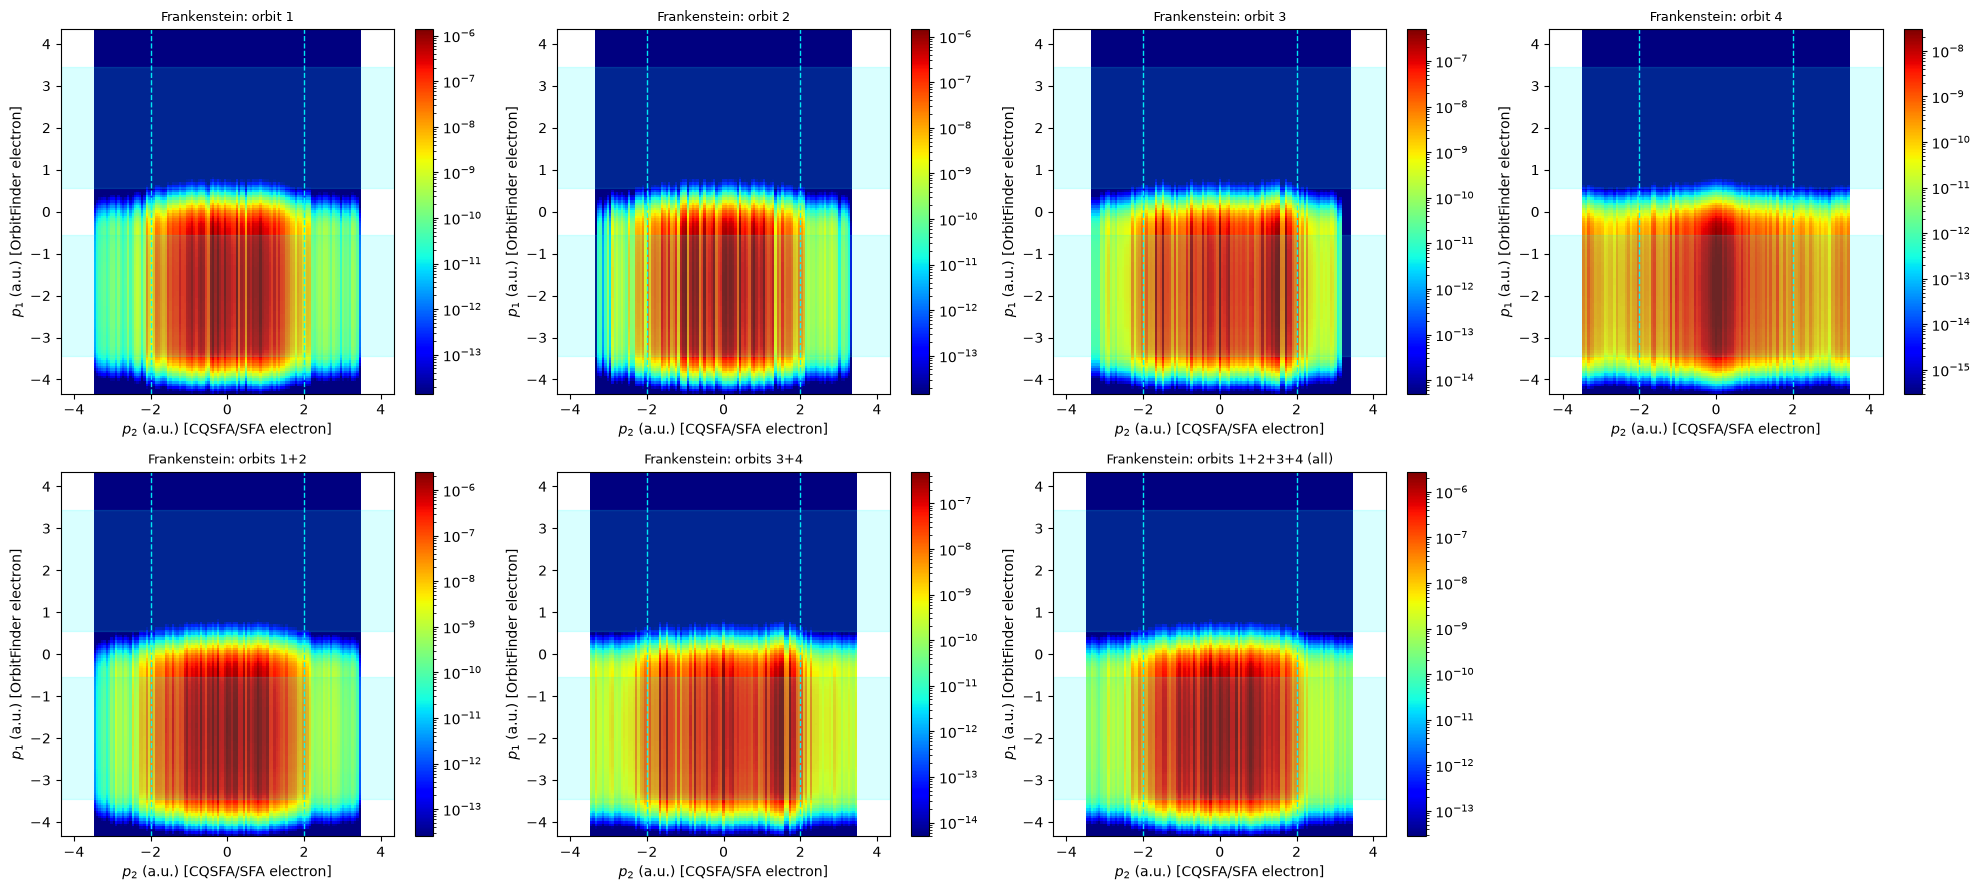

In [108]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, key in zip(axes.flat, combo_labels):
    d = np.abs(prob_by_combo[key])
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
    add_resi_bounds(ax)
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(f"Frankenstein: {combo_labels[key]}", fontsize=9)
    fig.colorbar(pcm, ax=ax)
axes.flat[-1].axis("off")  # only 7 combos, last panel unused
plt.tight_layout()
plt.show()

### Sanity check: raw final-momentum energy per orbit (no griddata/amplitude involved)

The panels above show electron 2's momentum support staying close to `+/-2` (pax units) for
every orbit, including 3/4 - not the clear extension past the direct bound expected from the
thesis excerpt. Before concluding anything physical, rule out a reconstruction artifact: `griddata`
only fills in wherever each orbit's own raw points land on OrbitFinder's grid, so its visual edge
reflects *coverage*, not necessarily a true amplitude cutoff. Check the raw
`Binned_Initial_Condition_Grid` `pf_z`/`pf_perp` (`df`, loaded in Section 2, no interpolation or
amplitude weighting at all) directly instead.

 orbit    count  max Ekin (a.u.)  max Ekin/Up  max |pf_z| max |pf_perp|
     1   240138            6.525         9.92       3.458         2.153
     2   286492            6.496         9.87       3.458         2.139
     3   296308            6.433         9.78       3.444         2.139
     4   389697            6.496         9.87       3.458         2.153


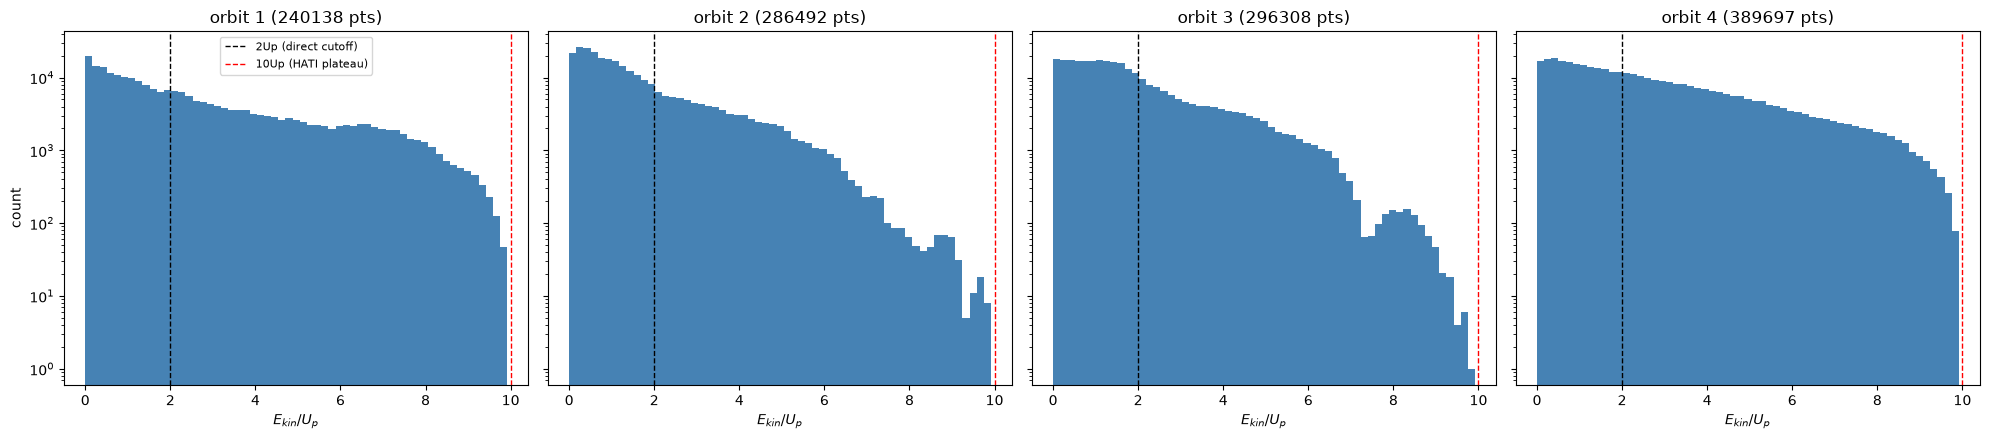

In [109]:
print(f"{'orbit':>6} {'count':>8} {'max Ekin (a.u.)':>16} {'max Ekin/Up':>12} {'max |pf_z|':>11} {'max |pf_perp|':>13}")
for orbit_num in (1, 2, 3, 4):
    d = df[df["orbit"] == orbit_num]
    Ekin = 0.5 * (d["pf_z"] ** 2 + d["pf_perp"] ** 2)
    print(f"{orbit_num:>6} {len(d):>8} {Ekin.max():>16.3f} {Ekin.max() / Up:>12.2f} "
          f"{d['pf_z'].abs().max():>11.3f} {d['pf_perp'].abs().max():>13.3f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
bins = np.linspace(0, df.apply(lambda r: 0.5 * (r["pf_z"] ** 2 + r["pf_perp"] ** 2), axis=1).max(), 60)
for ax, orbit_num in zip(axes, (1, 2, 3, 4)):
    d = df[df["orbit"] == orbit_num]
    Ekin = 0.5 * (d["pf_z"] ** 2 + d["pf_perp"] ** 2)
    ax.hist(Ekin / Up, bins=bins / Up, color="steelblue")
    ax.axvline(2, color="k", ls="--", lw=1, label="2Up (direct cutoff)")
    ax.axvline(10, color="r", ls="--", lw=1, label="10Up (HATI plateau)")
    ax.set_yscale("log")
    ax.set_xlabel(r"$E_{kin}/U_p$")
    ax.set_title(f"orbit {orbit_num} ({len(d)} pts)")
    if orbit_num == 1:
        ax.set_ylabel("count")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Replicating Shaaran, Nygren & Figueira de Morisson Faria, *PRA* **85**, 023423 (2012), Fig. 1

Three panels, each a genuine (p_parallel, p_perpendicular) marginal - the OTHER electron always
fully integrated out (not fixed/cut), matching the paper's Eq. (17)/(18):
- (a) electron 1 (OrbitFinder's own uniform-approximation electron), pure Coulomb-free SFA -
  marginalize `M_sfa_long` over ALL of electron 2 (both components).
- (b) electron 2, pure Coulomb-free SFA (same `M_sfa_long`) - marginalize over ALL of electron 1.
- (c) electron 2, stability-factor-only (`qPref`) - CQSFA_fwd's own native `Amplitude_Grid`
  already IS this marginal (electron 1 never appears in it), reused directly from Section 1.

Caveat: our own (p1,p2)_trans grid (`tax_half`) only covers the non-negative half (the
codebase's "HalfPerp" convention) - (a)/(b) mirror it to the negative side for a like-for-like
visual comparison to the paper's symmetric plots, relying on the system's known azimuthal
symmetry (no source of a +/-perp asymmetry here).

In [110]:
# (a)/(b): marginalize M_sfa_long over the OTHER electron's (long, trans) pair entirely.
# NOTE: tax_half (hence p1trans_w/p2trans_w) is the NON-POSITIVE half, so the raw weight is
# <=0 - use its magnitude here (a proper polar |p_perp| Jacobian), unlike prob_of() elsewhere
# where two negative factors are multiplied together and the sign cancels out automatically.

prob_e1_par_perp_sfa = (np.abs(M_sfa_long) ** 2 * np.abs(p2trans_w)).sum(axis=(1, 3))  # -> (p1_long, p1_trans)del M_sfa_long
prob_e2_par_perp_sfa = (np.abs(M_sfa_long) ** 2 * np.abs(p1trans_w)).sum(axis=(0, 2))  # -> (p2_long, p2_trans)

In [111]:
print(list(amp_quantities.keys()))
print("tax_half[:5] =", tax_half[:5], "tax_half[-5:] =", tax_half[-5:])
print("prob_e1_par_perp_sfa shape/max:", prob_e1_par_perp_sfa.shape, prob_e1_par_perp_sfa.max())

['bare', 'full', 'qpref']
tax_half[:5] = [-4.315 -4.253 -4.192 -4.13  -4.068] tax_half[-5:] = [-0.247 -0.185 -0.123 -0.062  0.   ]
prob_e1_par_perp_sfa shape/max: (141, 71) 1.3263333334268191e-11


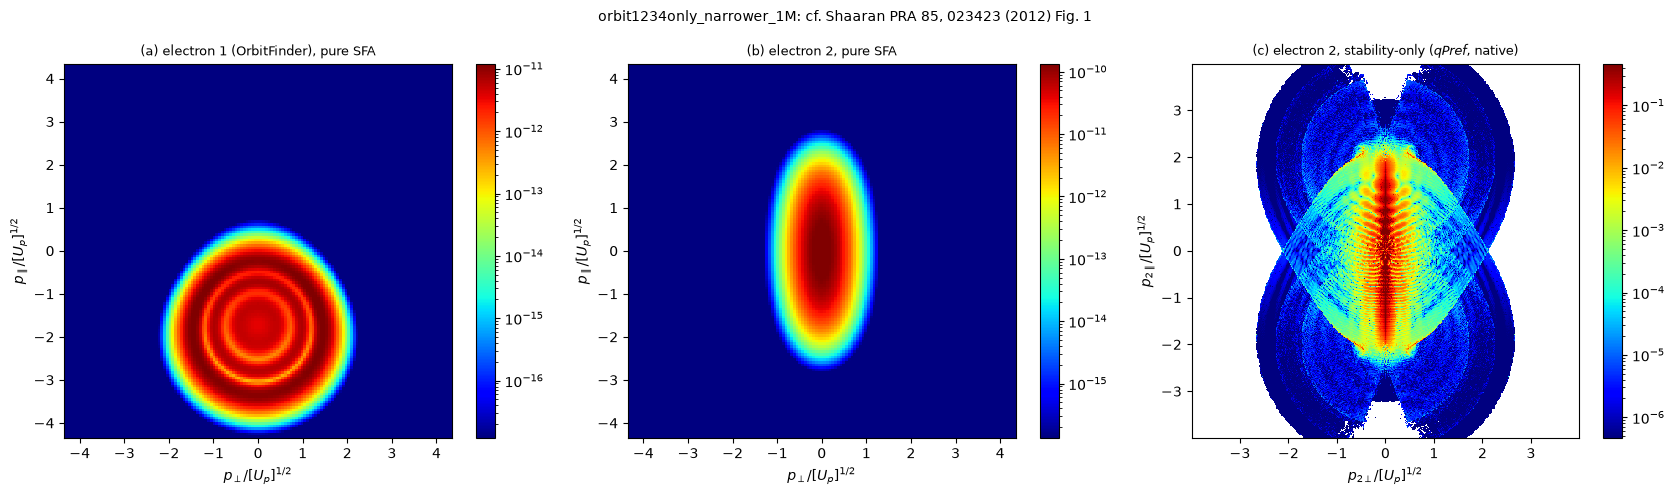

In [112]:
def mirror_perp(axis, data, trans_axis=-1):
    # `axis` (tax_half) is the NON-POSITIVE half (ascending, last entry ~0, since pax/tax_half
    # come from np.unique() sorted ascending and we take the first hsize entries) - mirror it
    # to the positive side for a full symmetric (-max..max) axis/data, no duplicate zero.
    trimmed = np.delete(data, -1, axis=trans_axis)  # drop the zero-valued slice before mirroring
    full_data = np.concatenate([data, np.flip(trimmed, axis=trans_axis)], axis=trans_axis)
    full_axis = np.concatenate([axis, -axis[:-1][::-1]])
    return full_axis, full_data


tax_full, e1_full = mirror_perp(tax_half, np.abs(prob_e1_par_perp_sfa))
_, e2_full = mirror_perp(tax_half, np.abs(prob_e2_par_perp_sfa))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, d, title in [
    (axes[0], e1_full, "(a) electron 1 (OrbitFinder), pure SFA"),
    (axes[1], e2_full, "(b) electron 2, pure SFA"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(tax_full, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{\perp}/[U_p]^{1/2}$")
    ax.set_ylabel(r"$p_{\parallel}/[U_p]^{1/2}$")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)

# (c): reuse Section 1's native amp_quantities directly (own local mask/axis, no forward
# reference to Section 6's variables which haven't been defined yet at this point).
p2_par_su_c = pz_amp / np.sqrt(Up)
p2_perp_su_c = py_amp / np.sqrt(Up)
par_mask_c = np.abs(p2_par_su_c) <= 4
perp_mask_c = np.abs(p2_perp_su_c) <= 4
d_c = amp_quantities["qpref"][np.ix_(par_mask_c, perp_mask_c)]
mask = d_c > 0
vmax = np.percentile(d_c[mask], 99.5) if mask.any() else 1.0
pcm = axes[2].pcolormesh(p2_perp_su_c[perp_mask_c], p2_par_su_c[par_mask_c], d_c, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")

axes[2].set_xlabel(r"$p_{2\perp}/[U_p]^{1/2}$")
axes[2].set_ylabel(r"$p_{2\parallel}/[U_p]^{1/2}$")
axes[2].set_title("(c) electron 2, stability-only ($qPref$, native)", fontsize=9)
fig.colorbar(pcm, ax=axes[2])

fig.suptitle(f"{RUN_TAG}: cf. Shaaran PRA 85, 023423 (2012) Fig. 1", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Direct comparison to Shaaran, Nygren & Figueira de Morisson Faria, *PRA* **85**, 023423 (2012),
Fig. 1(c,d)

All earlier comparisons in this notebook (Sections 3-5) used the JOINT (p1, p2) distribution -
either integrated over both electrons' transverse momenta, or a slice at a FIXED p1/p2 value.
Shaaran's Fig. 1(c,d), however, plots electron 2's OWN marginal transition probability
`|M^(2)(p2)|^2` (Eq. 18) directly in its (p2_parallel, p2_perpendicular) plane, with electron 1
fully integrated out (not fixed to any particular value) - a genuinely different quantity from
our p1=-2/p2=0.1 cuts. CQSFA_fwd's native `Amplitude_Grid` (Section 1) is already exactly this
marginal (electron 1 never appears as an axis in it at all), so no new data/interpolation is
needed - just re-plot it zoomed/rescaled to the paper's own convention: p_parallel (y-axis) in
[-2,2] and p_perpendicular (x-axis) in [-1,1], both in sqrt(Up) units (paper's `[Up]^1/2`).

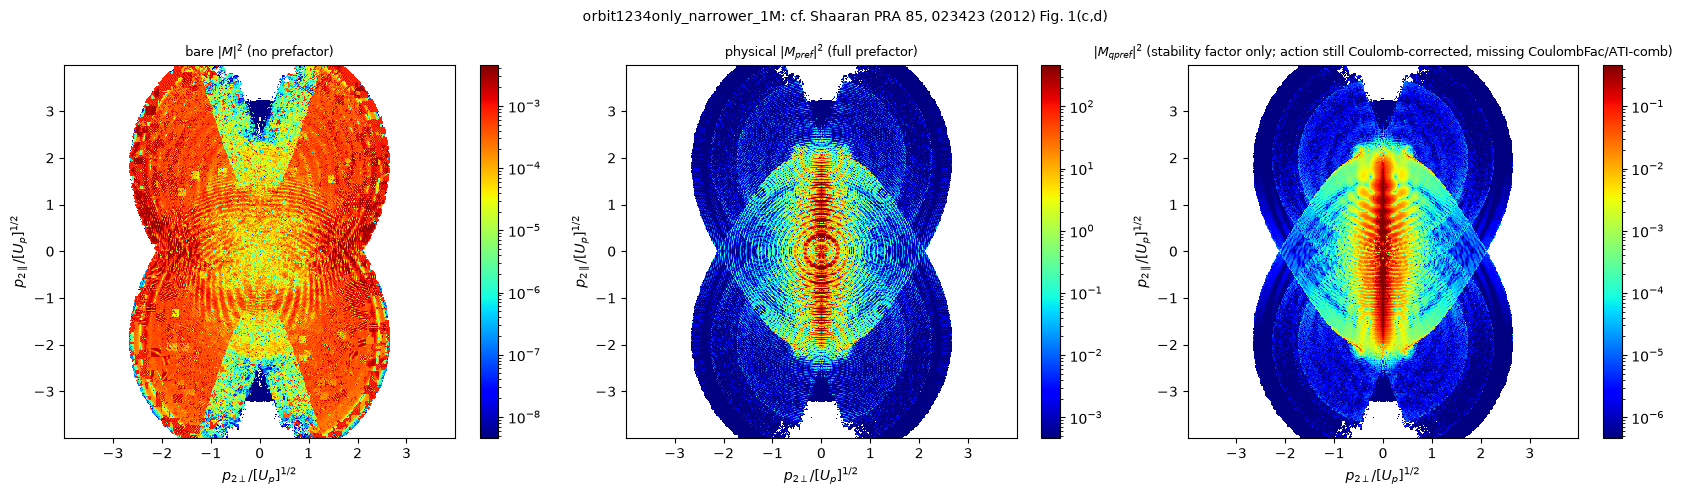

In [113]:
p2_par_su = pz_amp / np.sqrt(Up)    # p2_long (parallel to field) in sqrt(Up) units, matches paper's p_par
p2_perp_su = py_amp / np.sqrt(Up)   # p2_trans (perpendicular) in sqrt(Up) units, matches paper's p_perp
par_mask = np.abs(p2_par_su) <= 4
perp_mask = np.abs(p2_perp_su) <= 4

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (key, d) in zip(axes, amp_quantities.items()):
    d_zoom = d[np.ix_(par_mask, perp_mask)]  # d's native axes are (p_long, p_trans) - no transpose needed
    mask = d_zoom > 0
    vmax = np.percentile(d_zoom[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(p2_perp_su[perp_mask], p2_par_su[par_mask], d_zoom, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2\perp}/[U_p]^{1/2}$")
    ax.set_ylabel(r"$p_{2\parallel}/[U_p]^{1/2}$")
    ax.set_title(TITLES[key], fontsize=9)
    fig.colorbar(pcm, ax=ax)
fig.suptitle(f"{RUN_TAG}: cf. Shaaran PRA 85, 023423 (2012) Fig. 1(c,d)", fontsize=10)
plt.tight_layout()
plt.show()